# WH - Limit Plots

This notebook plots:

- 1D Brazil limit plots which show the observed and expected xsection limits as a function of $m_s$ for a given $m_{\phi}$, T and decay mode.  
- 2D limit plot of the observed excluded mu value as a function of $m_{\phi}$ (x-axis) and T (y-axis). 
- Summary plots: showing the $\mu=1$ exclusion limit for every value of $m_s$ and decay mode.

Using functions in `plot_utils.py`.

Use the Outline to navigate to the desired section.

In [1]:
%config InlineBackend.figure_format = 'retina'
import os
import matplotlib.pyplot as plt
import plot_utils as utils

plt.style.use('physics.mplstyle')

import mplhep as hep
hep.style.use("CMS")

In [2]:
# parameters
itag = '../cards/Combined/'

# outDir = '/home/submit/{}/public_html/SUEP/limits/debug/'.format(os.environ['USER'])
outDirAN = '/home/submit/{}/SUEP/AN-23-183/images/'.format(os.environ['USER'])
# outDirPaper = '/home/submit/{}/SUEP/EXO-23-002/'.format(os.environ['USER'])
# outDirSupp = '/home/submit/{}/SUEP/EXO-23-002/supplementary/'.format(os.environ['USER'])

saveToAN = False
saveToPaper = False

# if not os.path.isdir(outDir): os.mkdir(outDir)

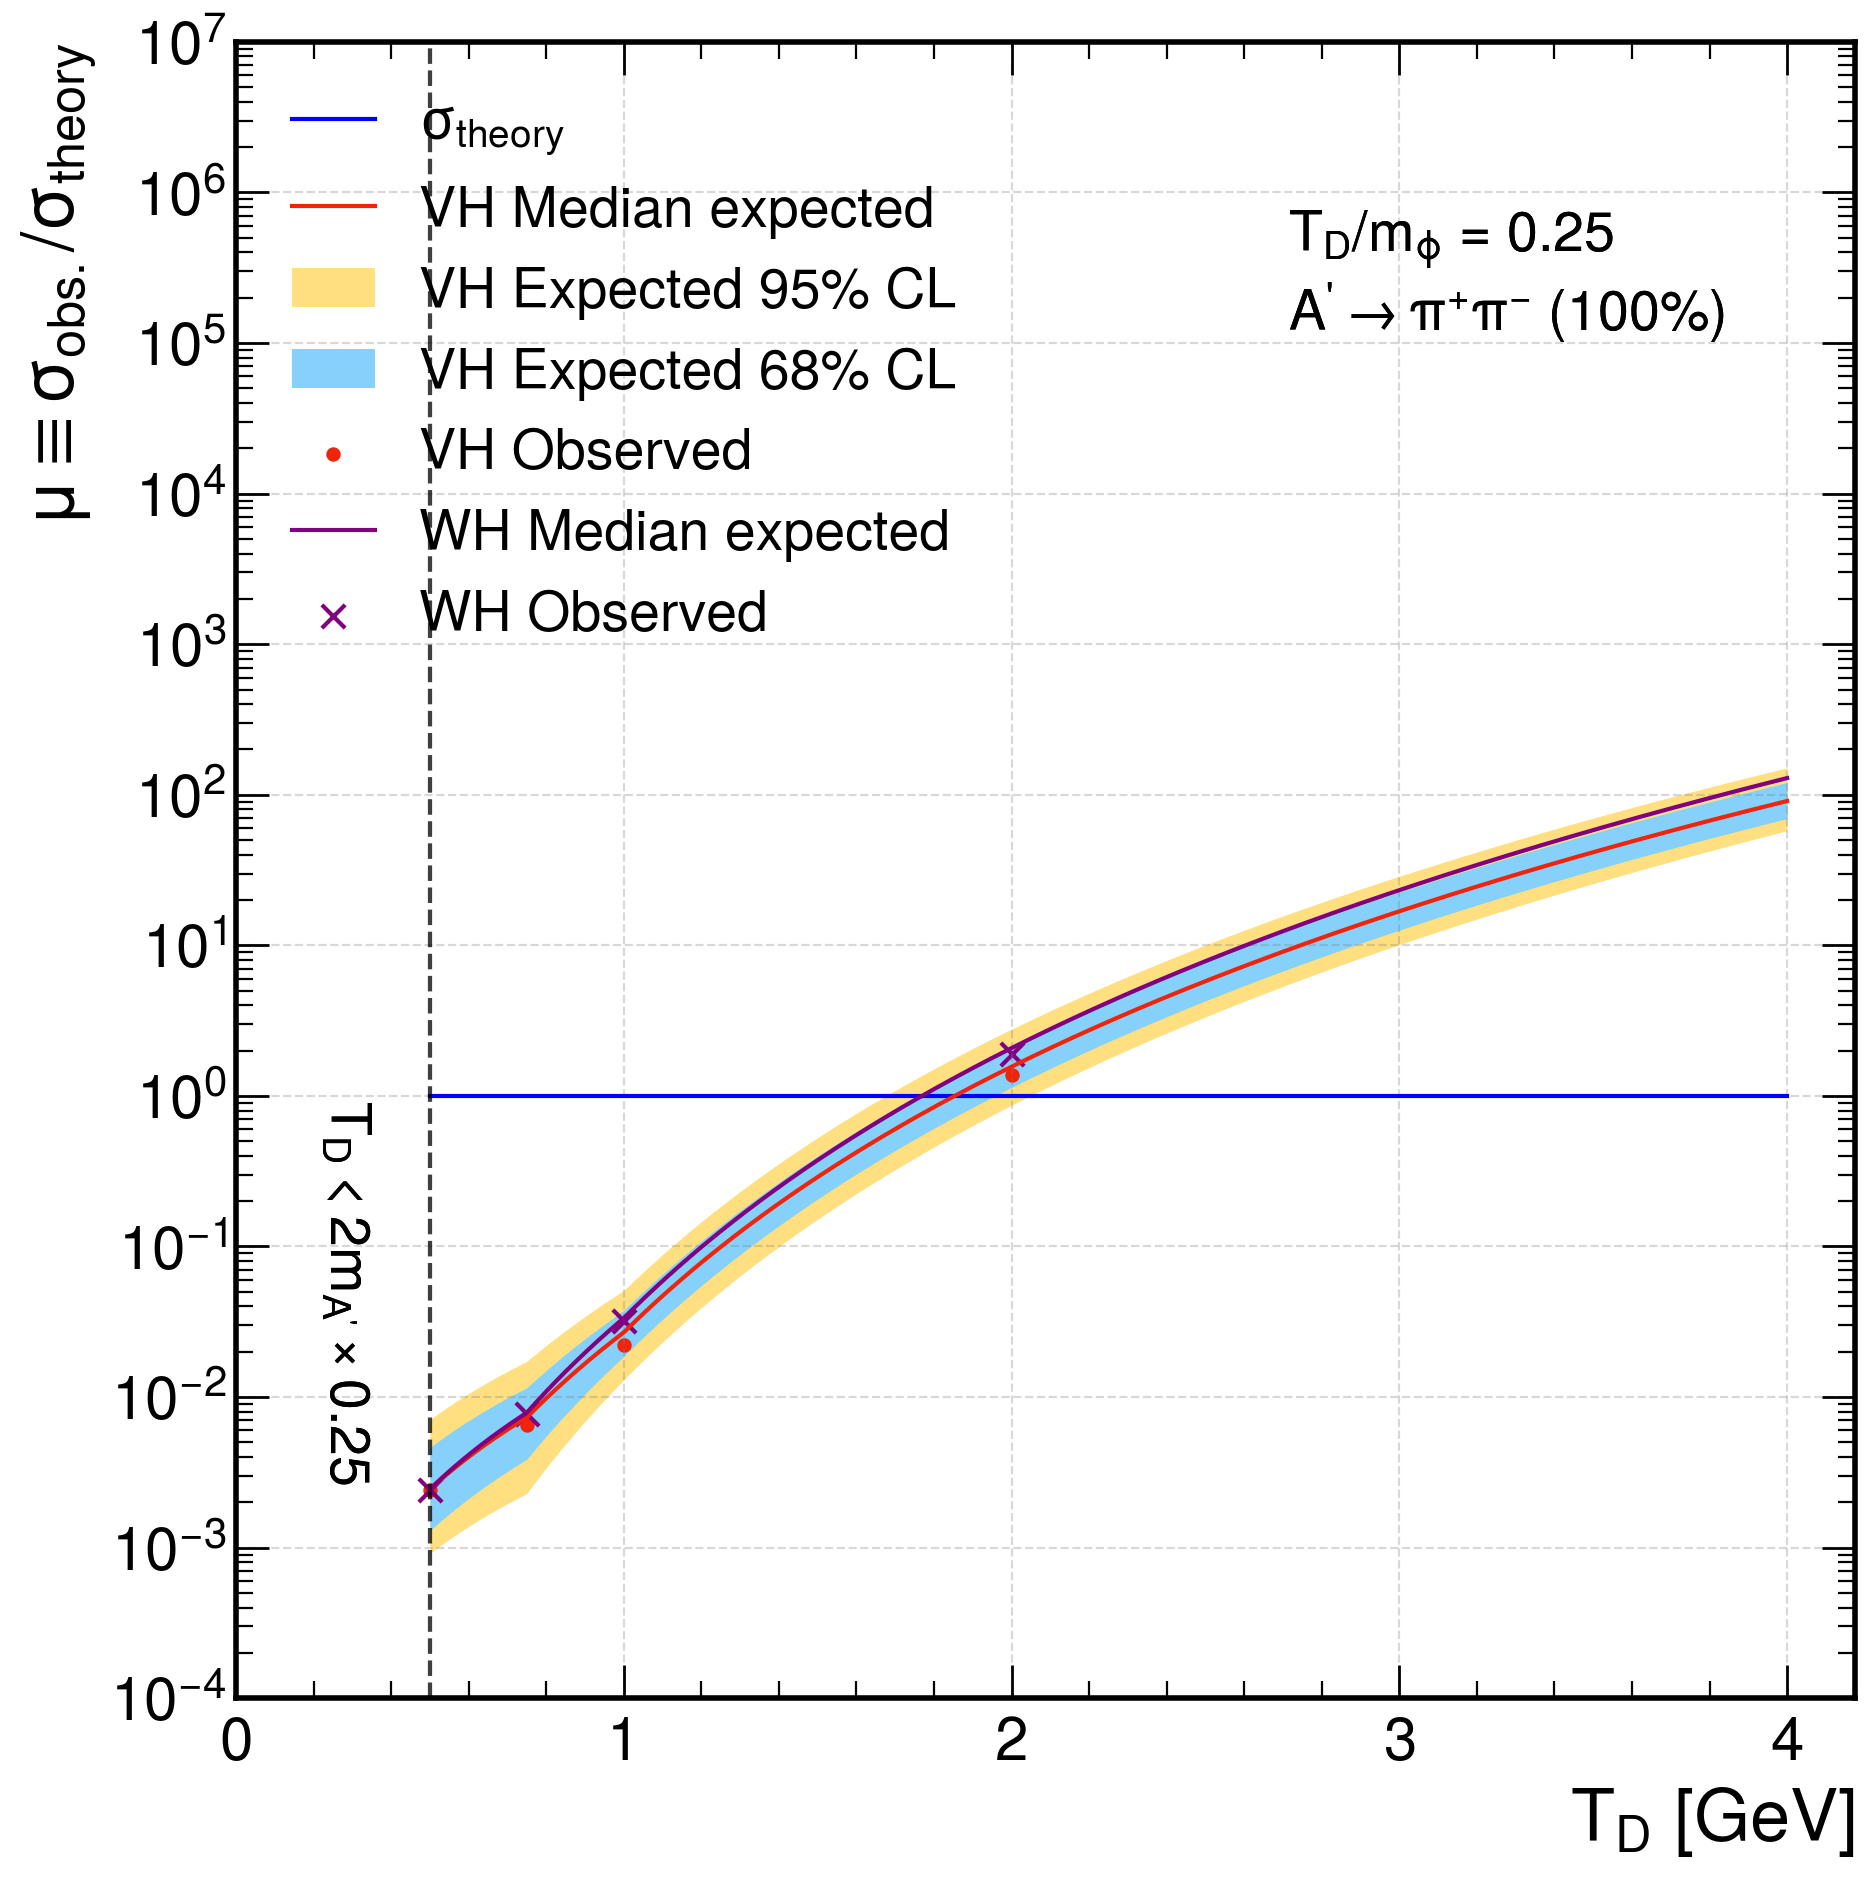

In [5]:
fig = utils.plot_mphi_by_T_limits(
    temp_by_mphi=0.25, ms=125, decay='generic',
    path=itag,
    obs_marker='.', method='AsymptoticLimits',
    analysis='vh', mu_limit=True, legend_label='VH '
)
fig = utils.plot_mphi_by_T_limits(
    temp_by_mphi=0.25, ms=125, decay='generic',
    path='../cards/WH_1_25/',
    method='AsymptoticLimits',
    analysis='wh', mu_limit=True,
    ax=fig.axes[0],
    exp_alpha=0.5,
    obs_marker='x',
    bands=False,
    color='purple',
    legend_label = 'WH '
)

## 2D Limits: $m_{\phi}$, T scan

In [4]:
import numpy as np
zh = np.loadtxt("SRCR_generic_limAsy.txt", delimiter=":")
norm = 0.909
obs = zh[:,-1]
mPhi = zh[:,1]
T = zh[:,2]
s2m = zh[:, 3]
s1m = zh[:, 4]
exp = zh[:, 5]
s1p = zh[:, 6]
s2p = zh[:, 7]

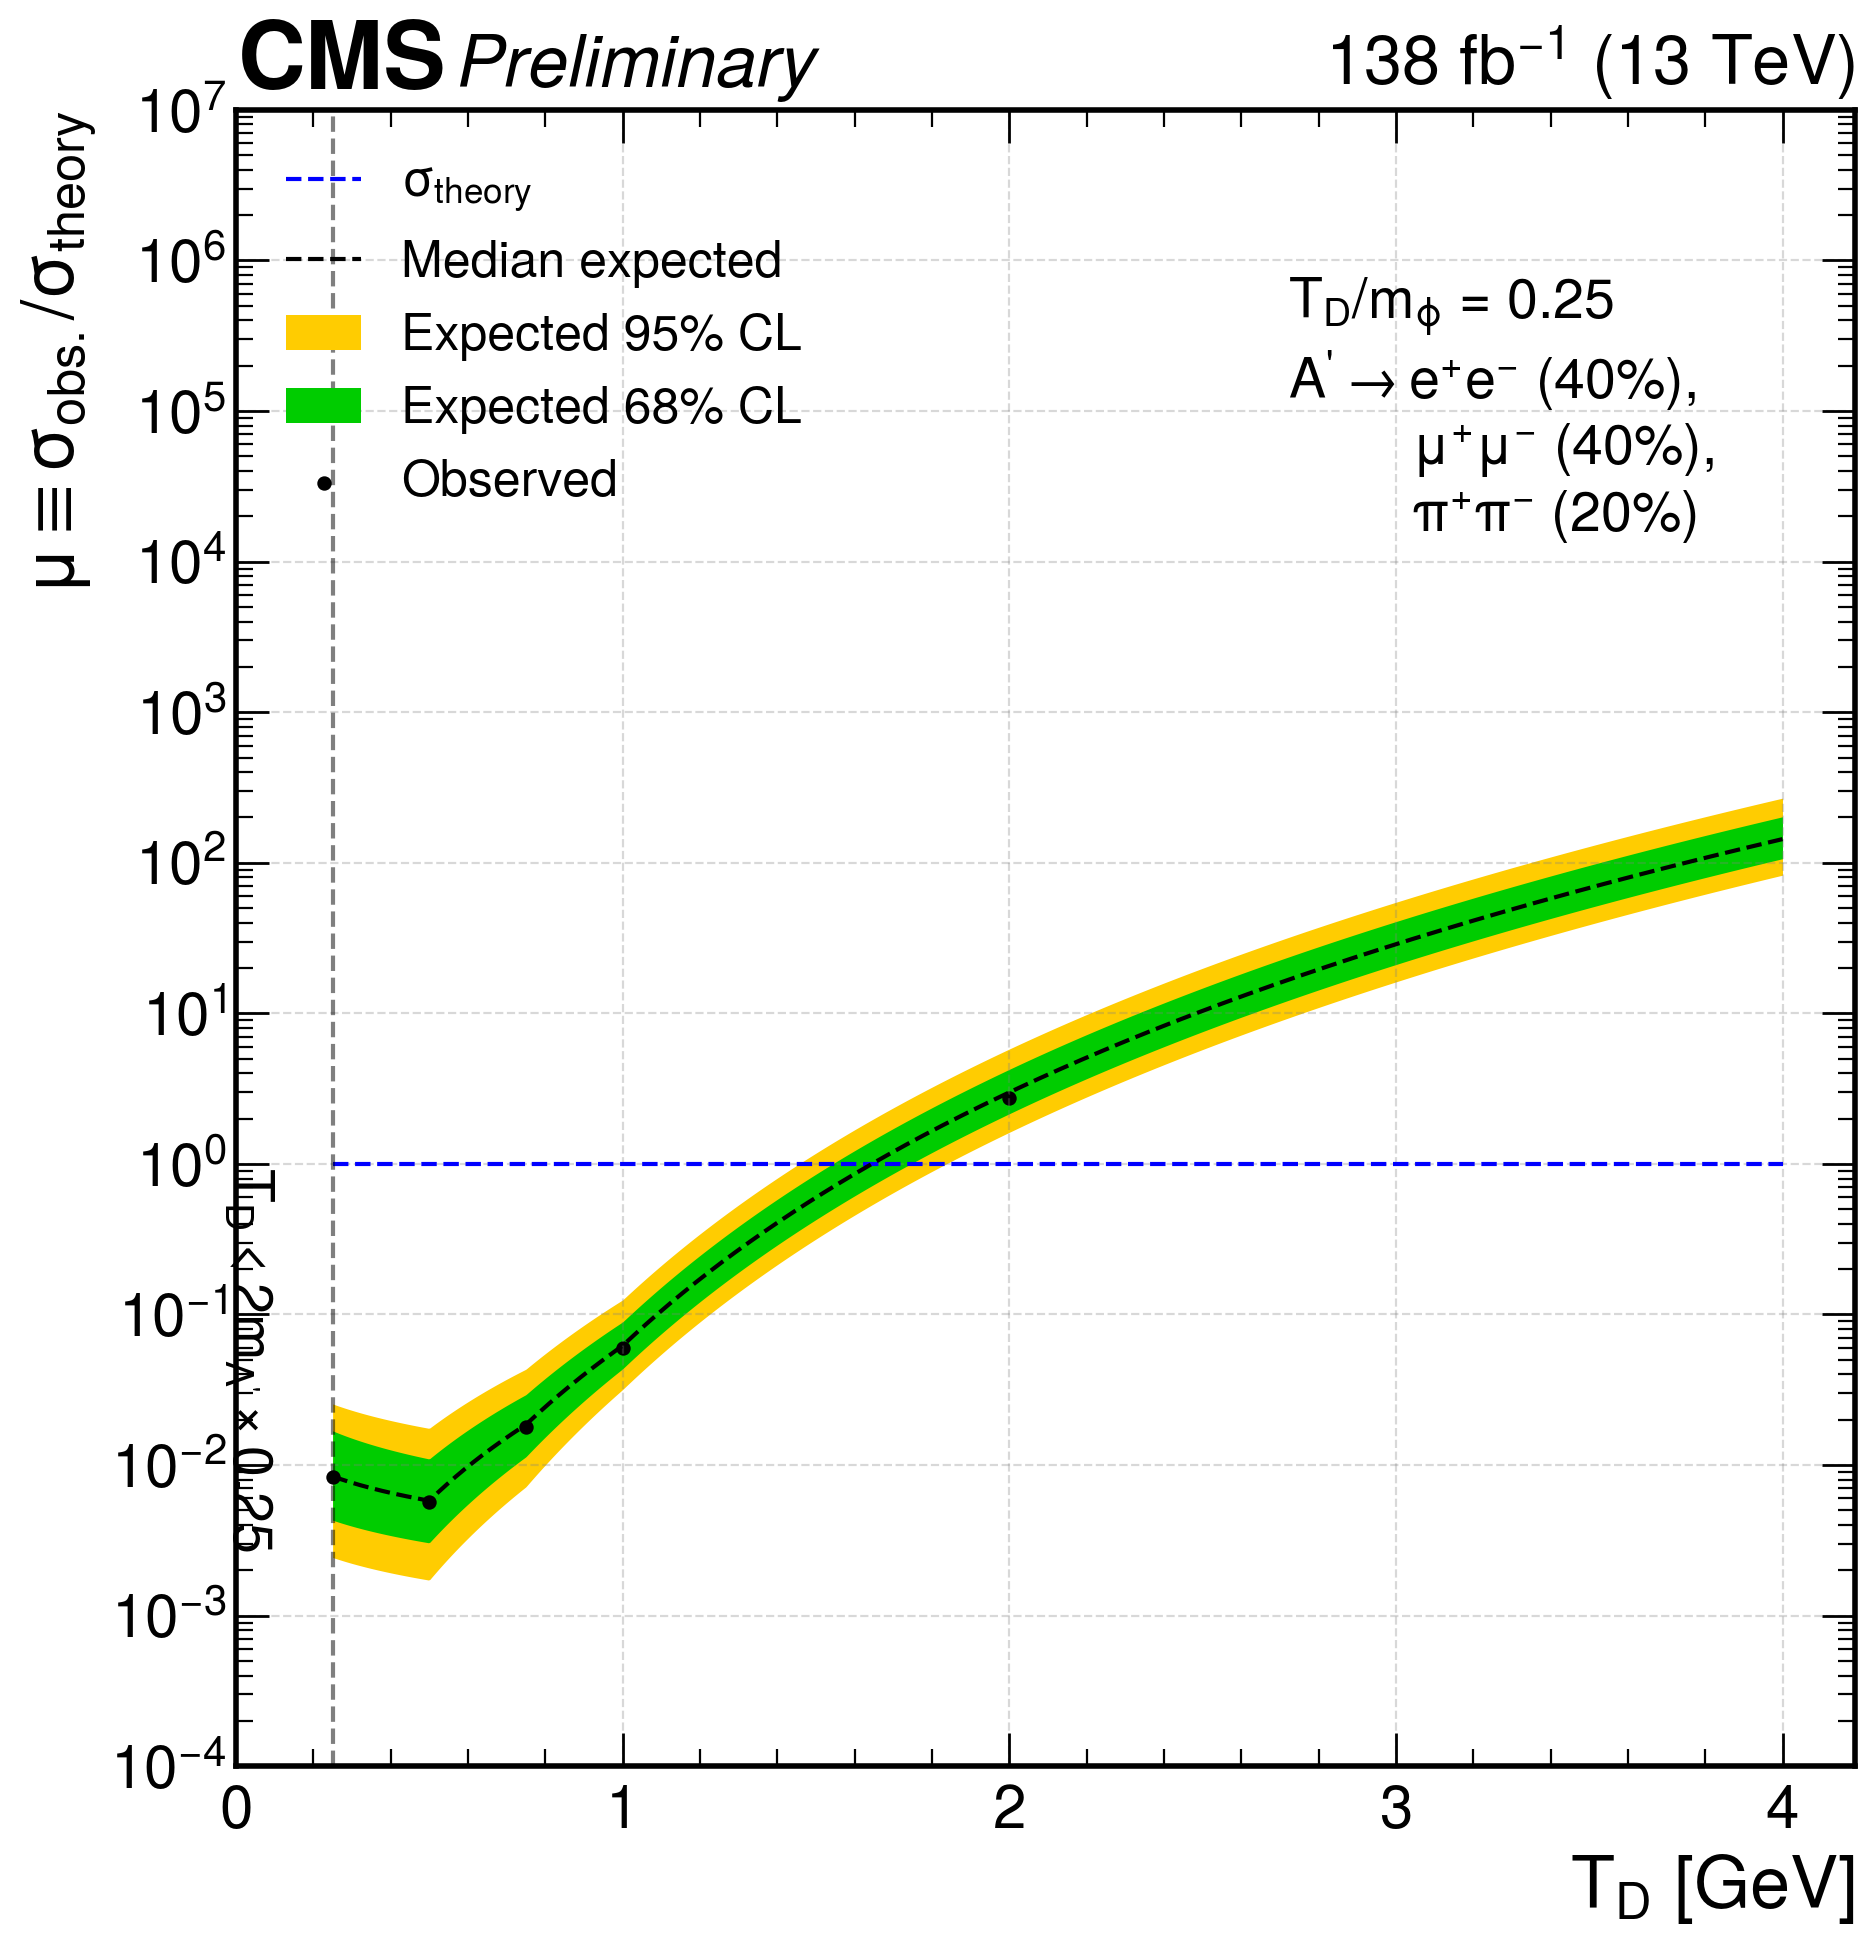

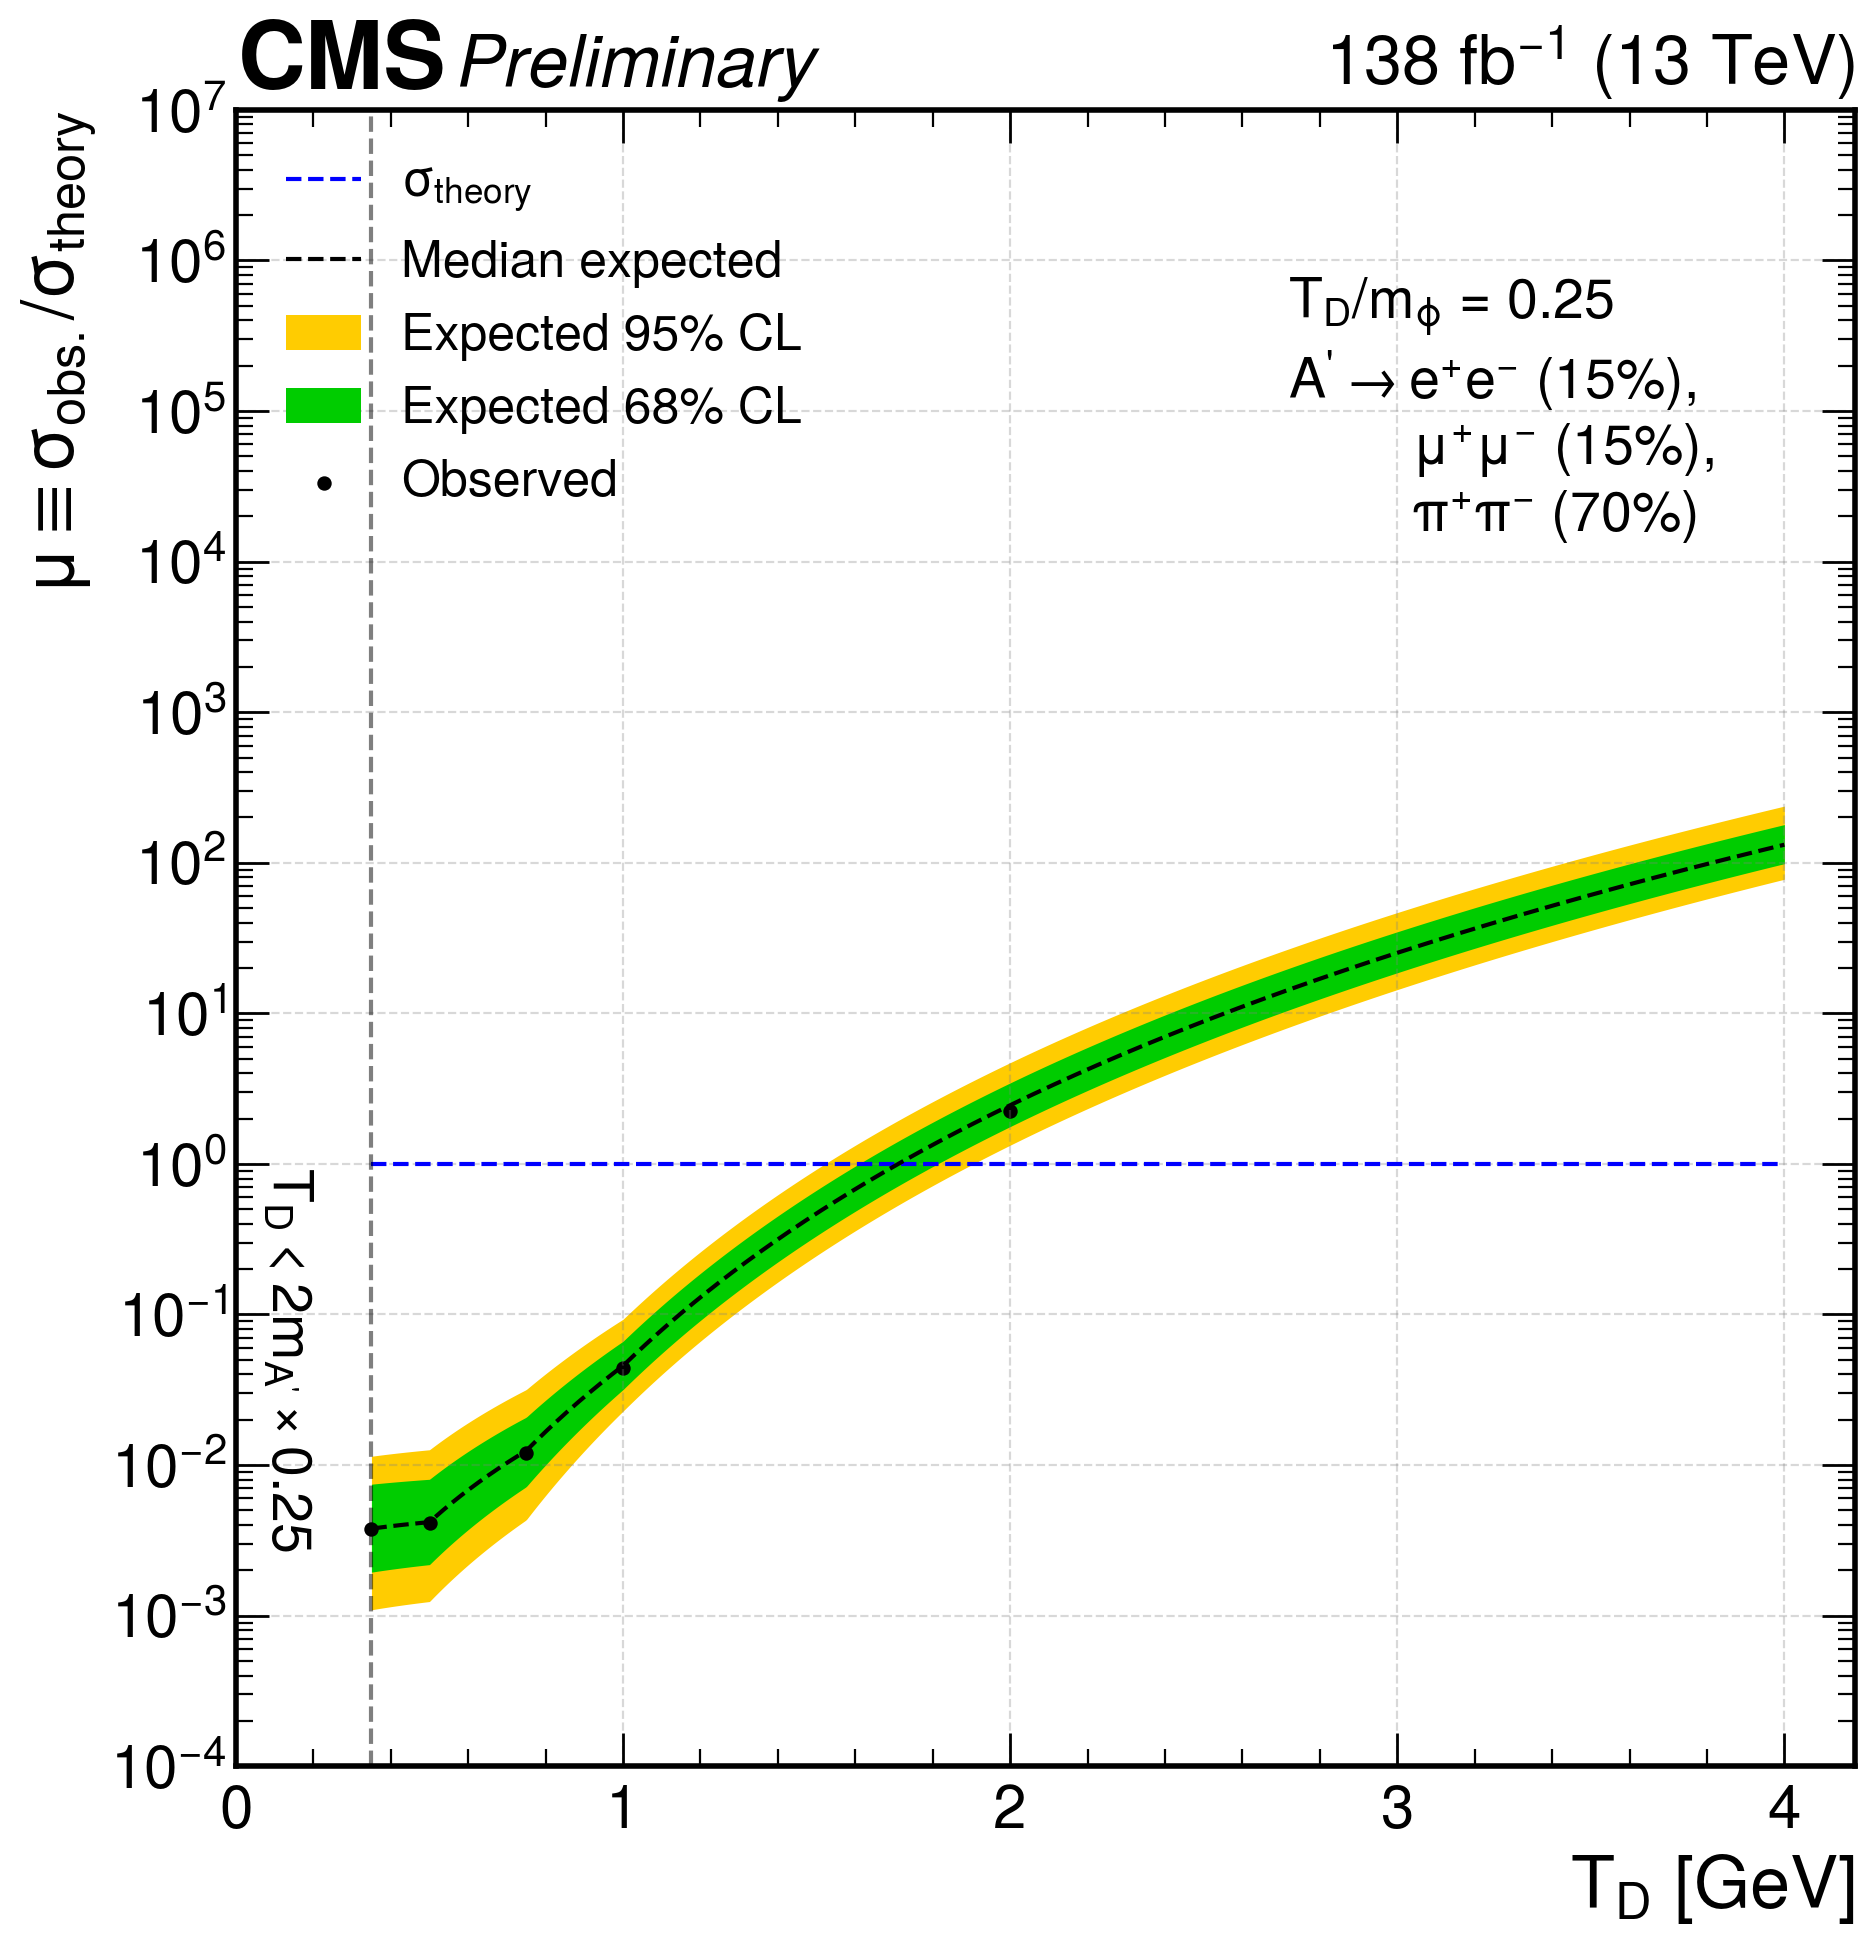

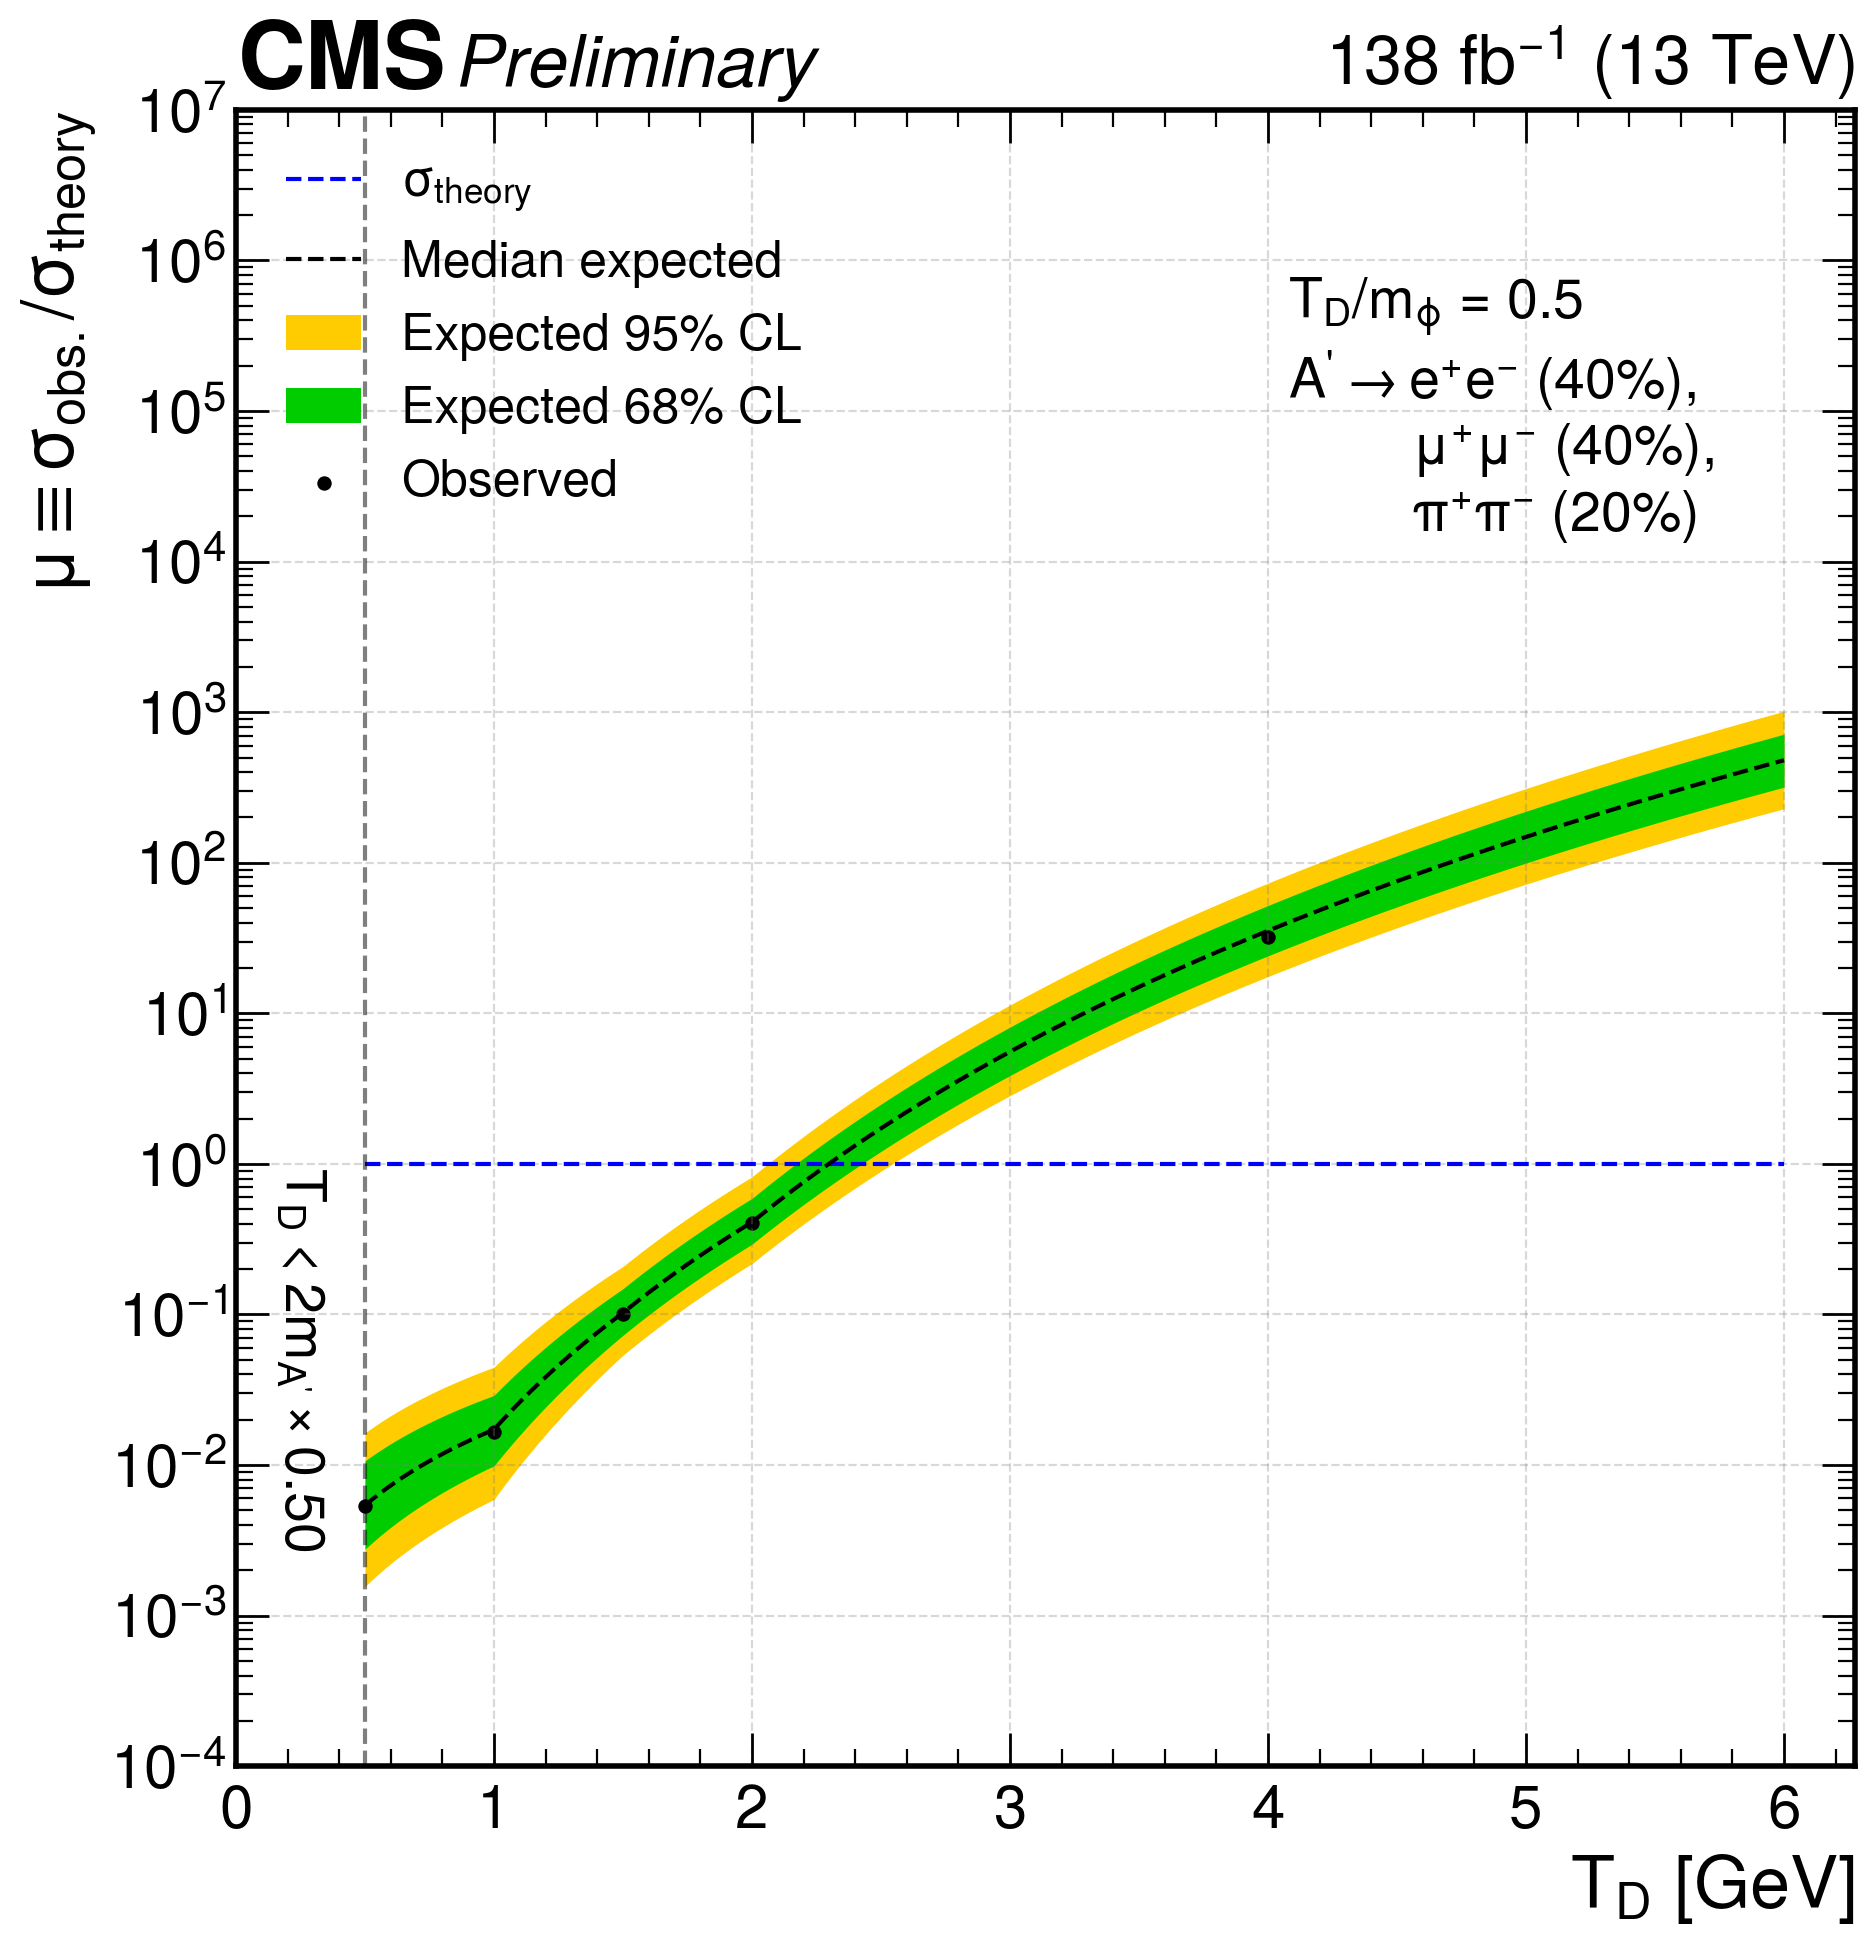

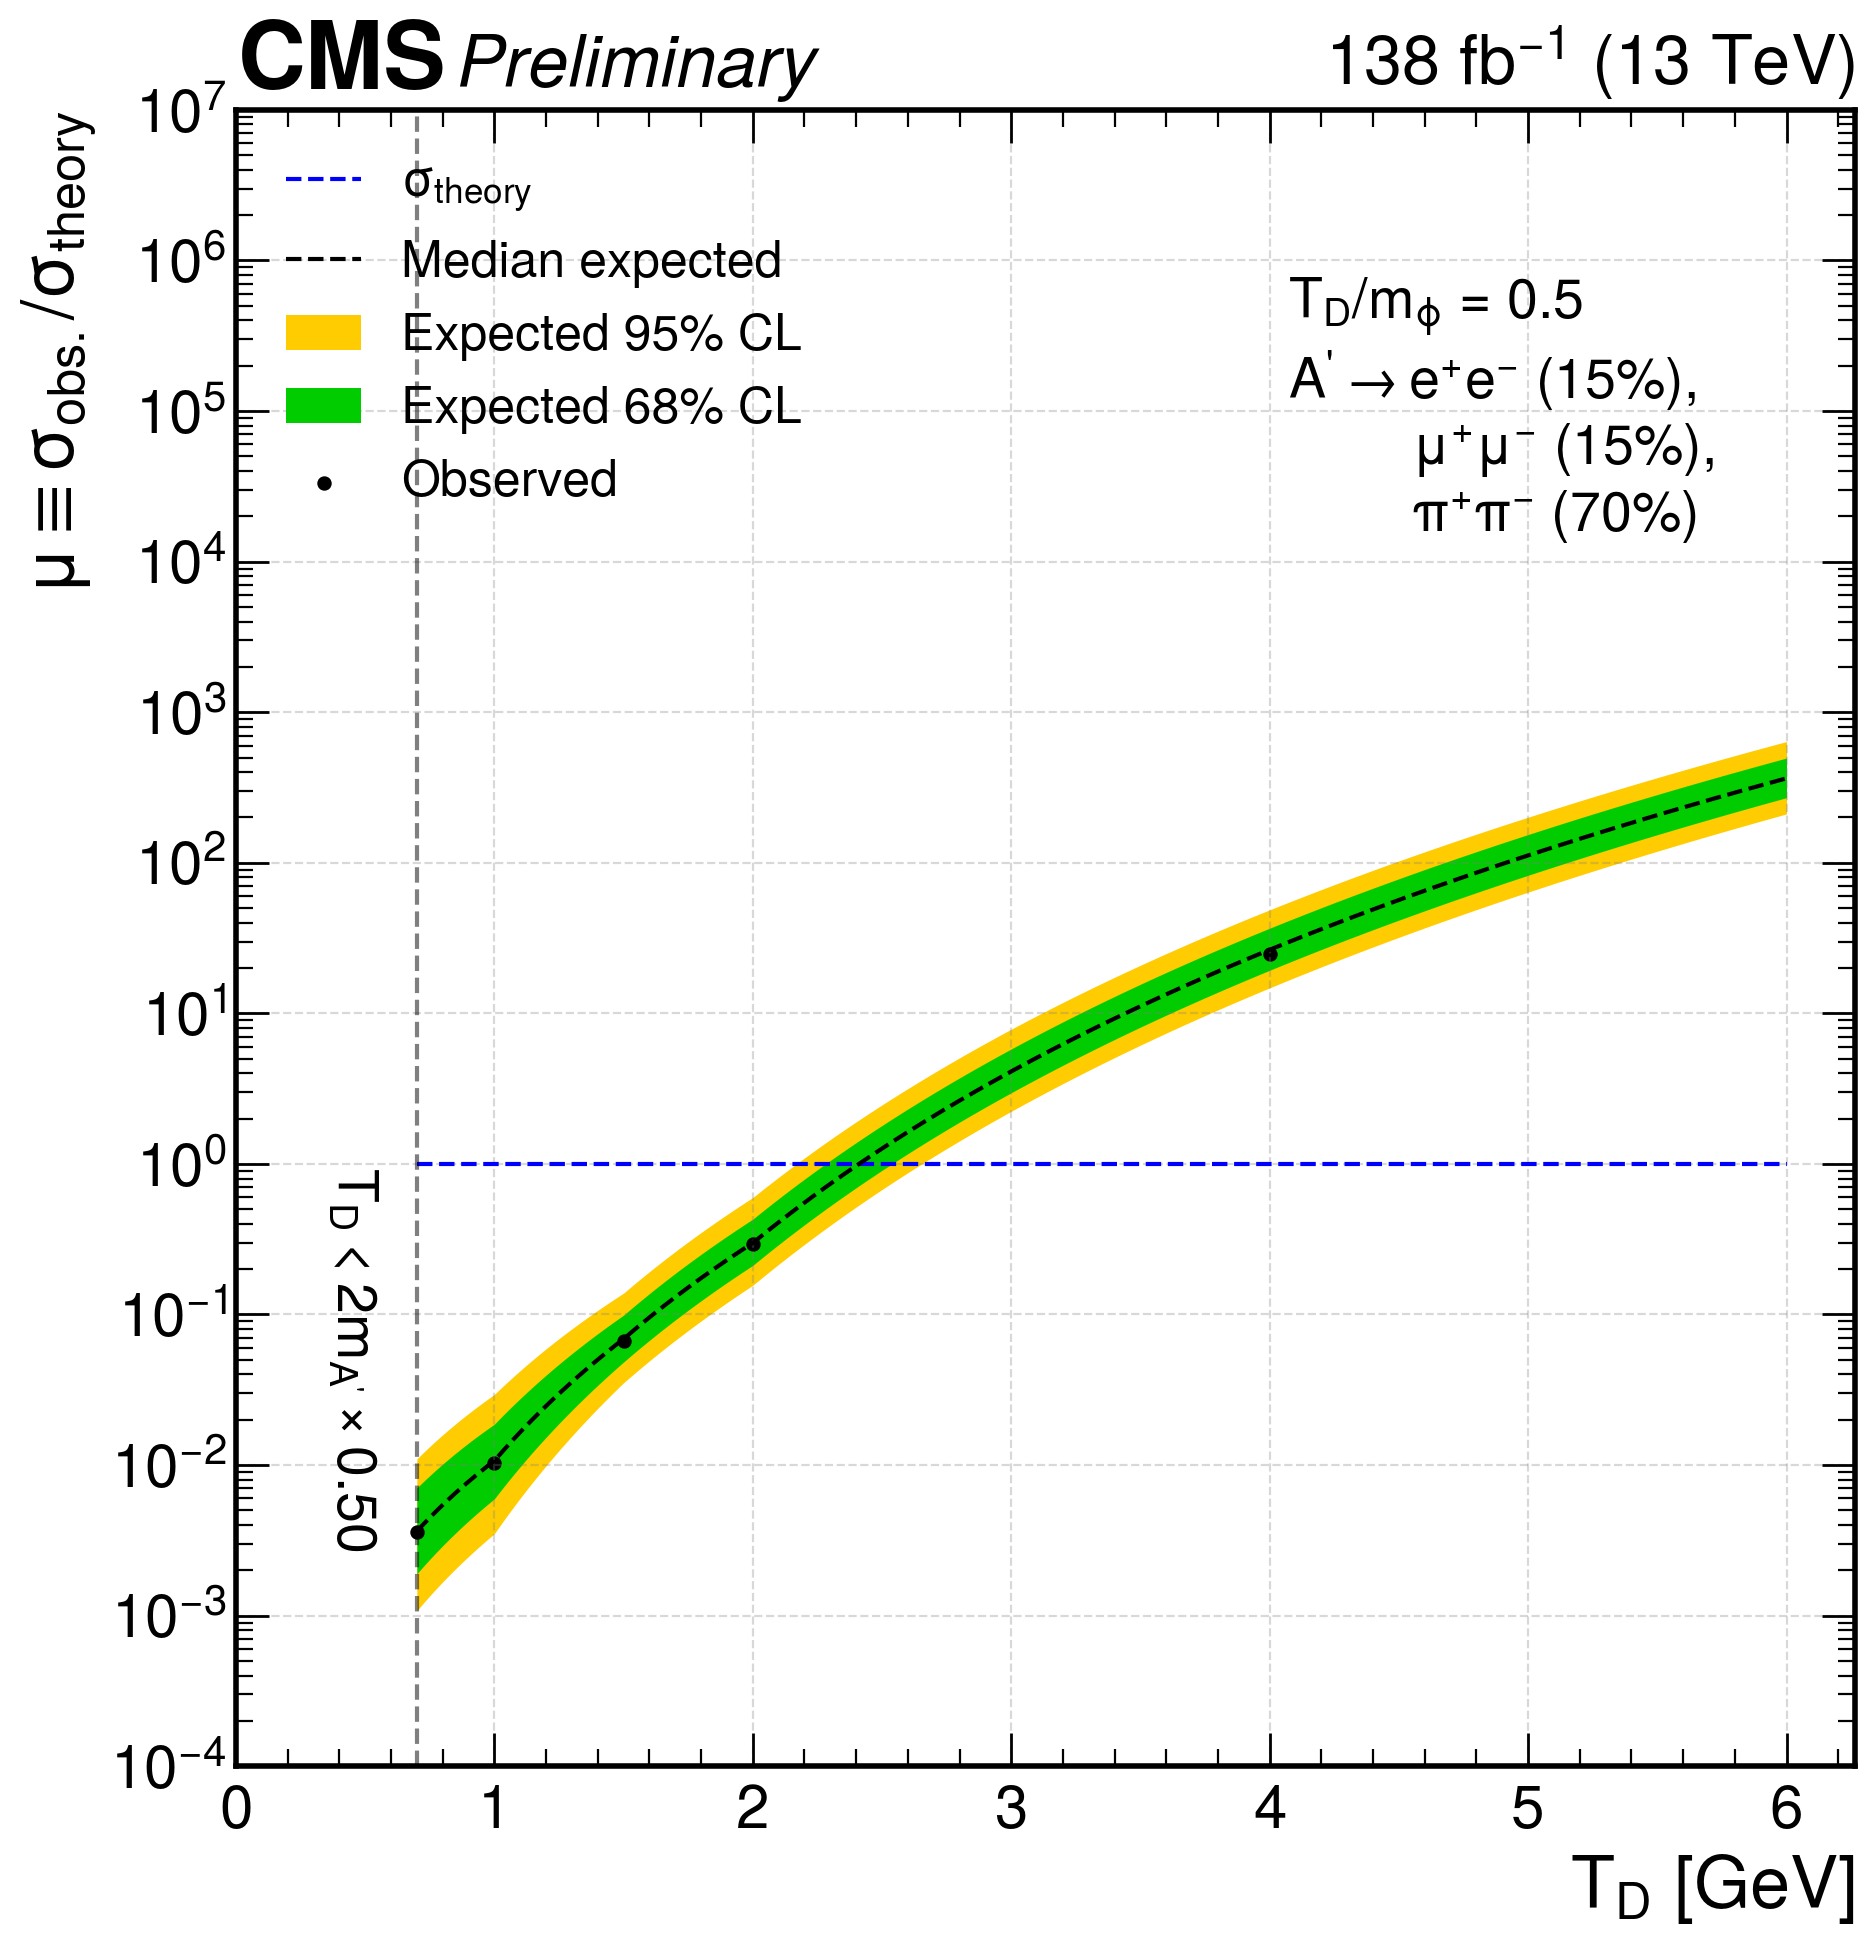

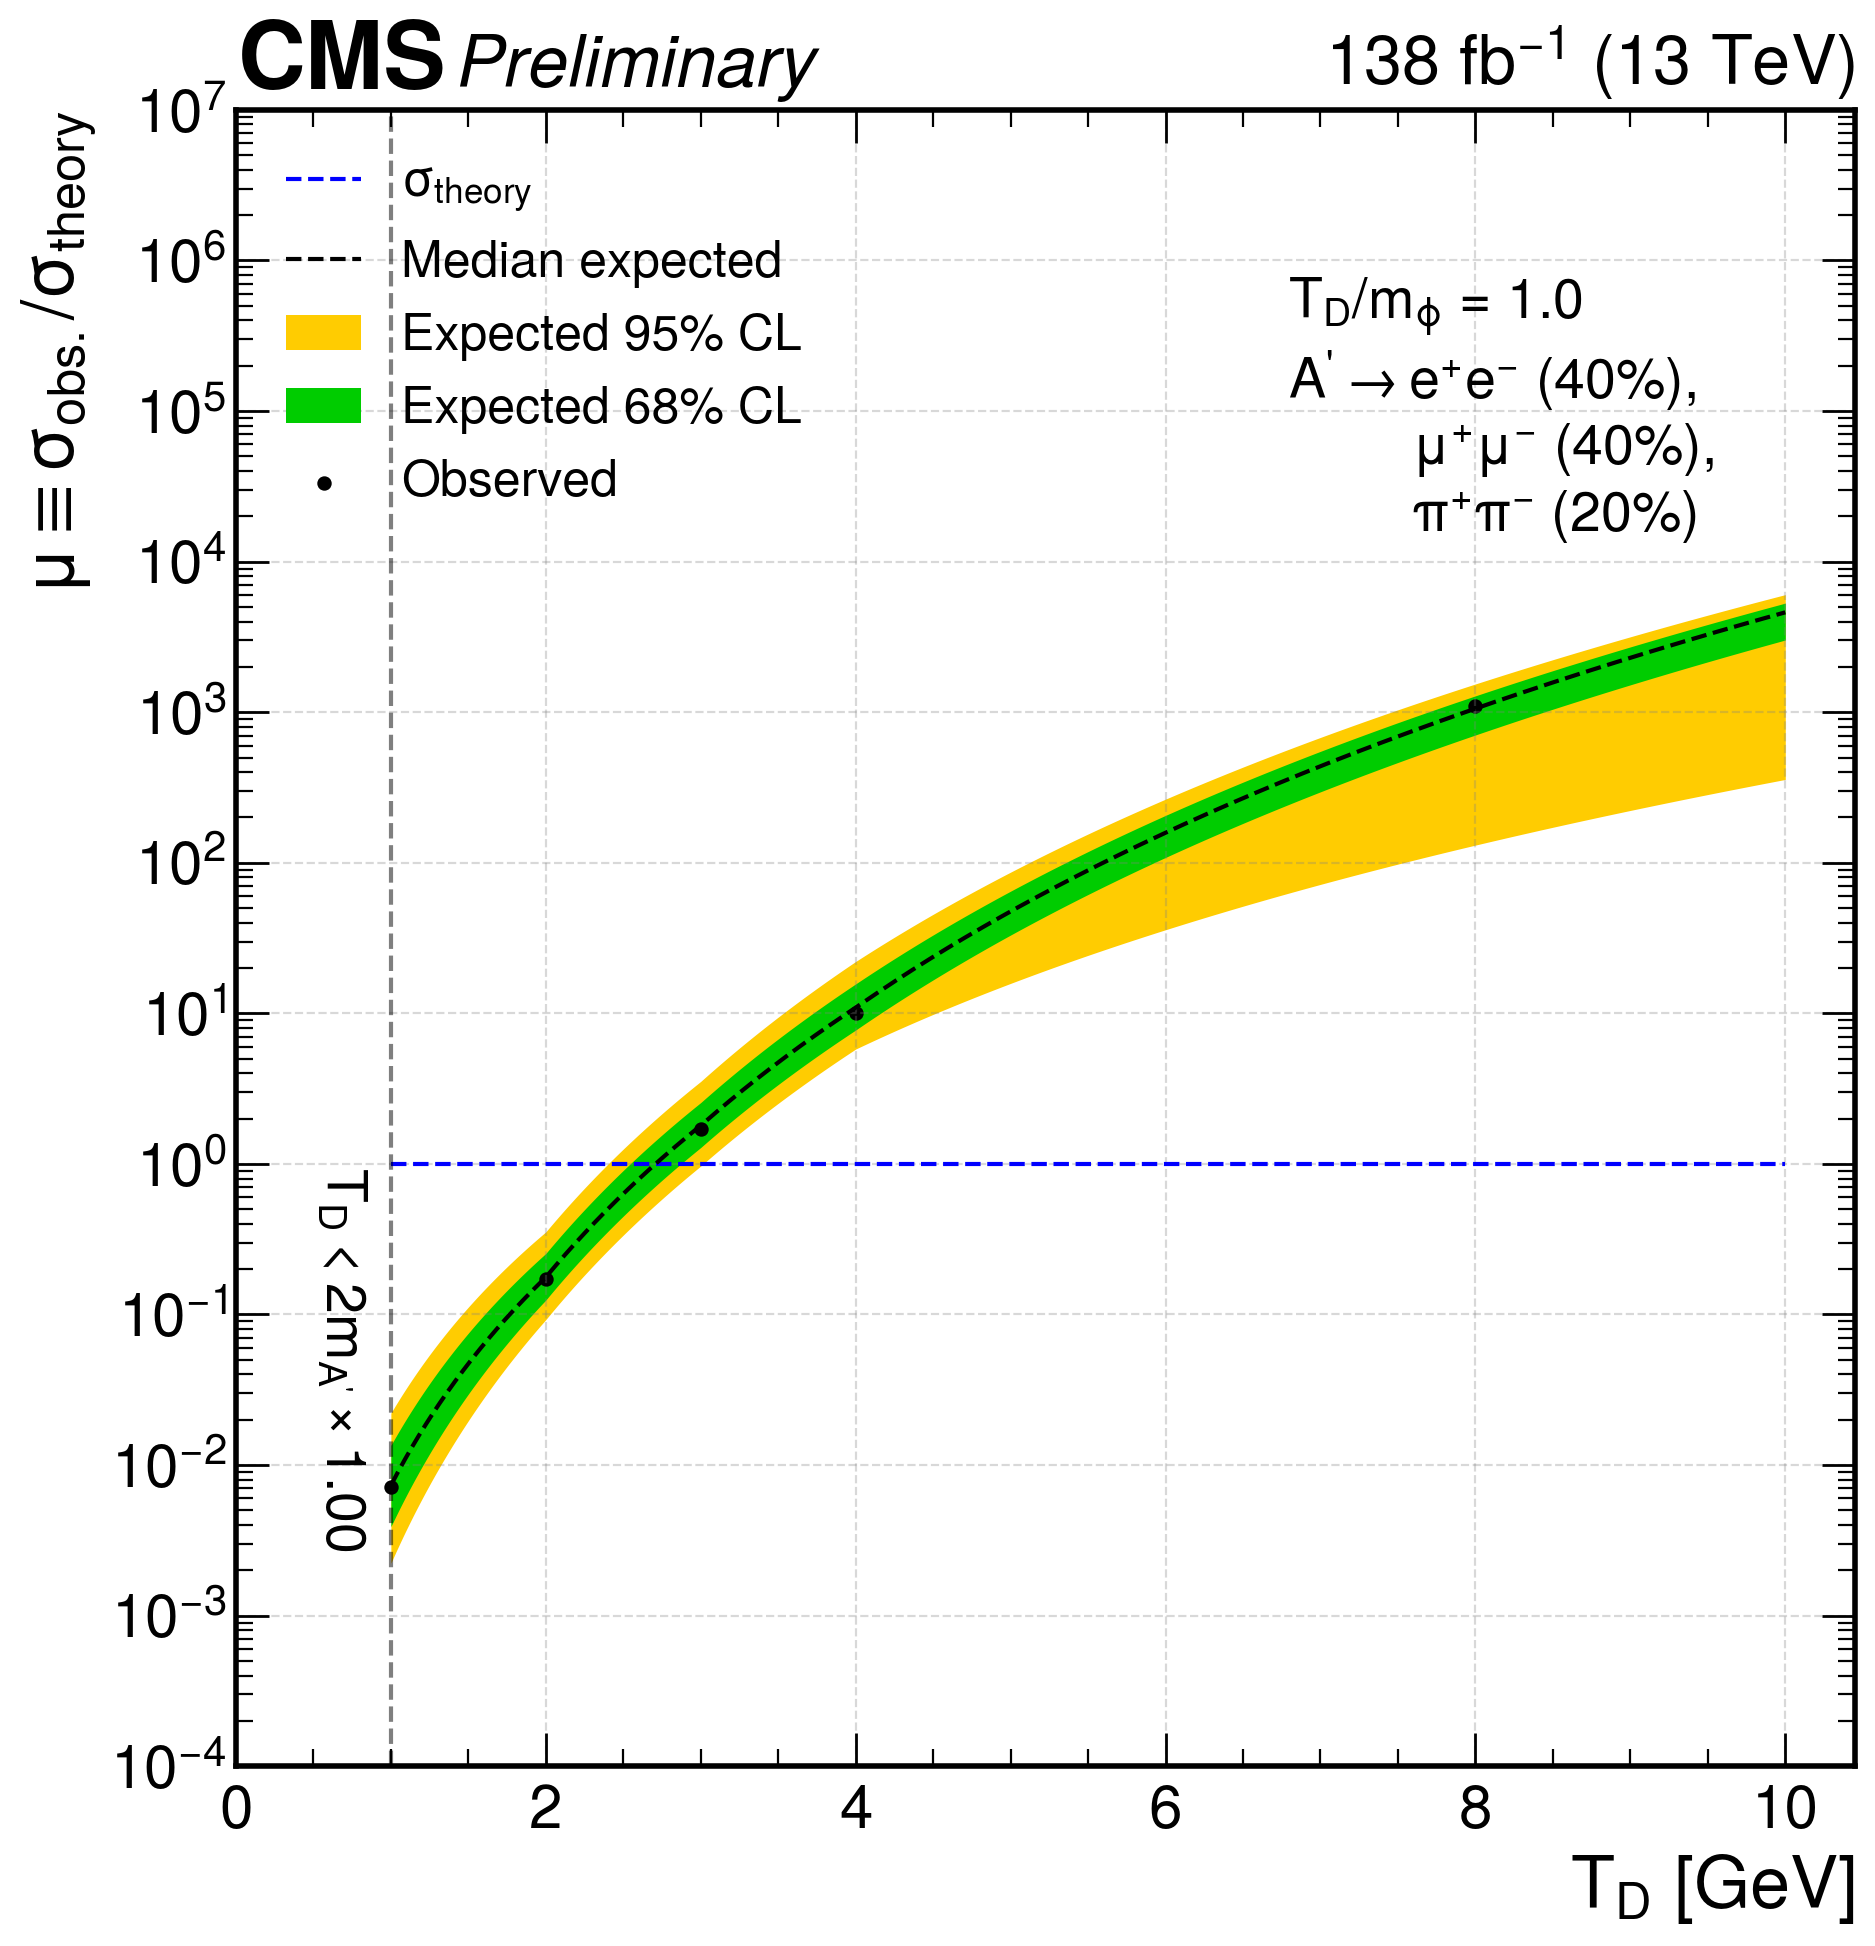

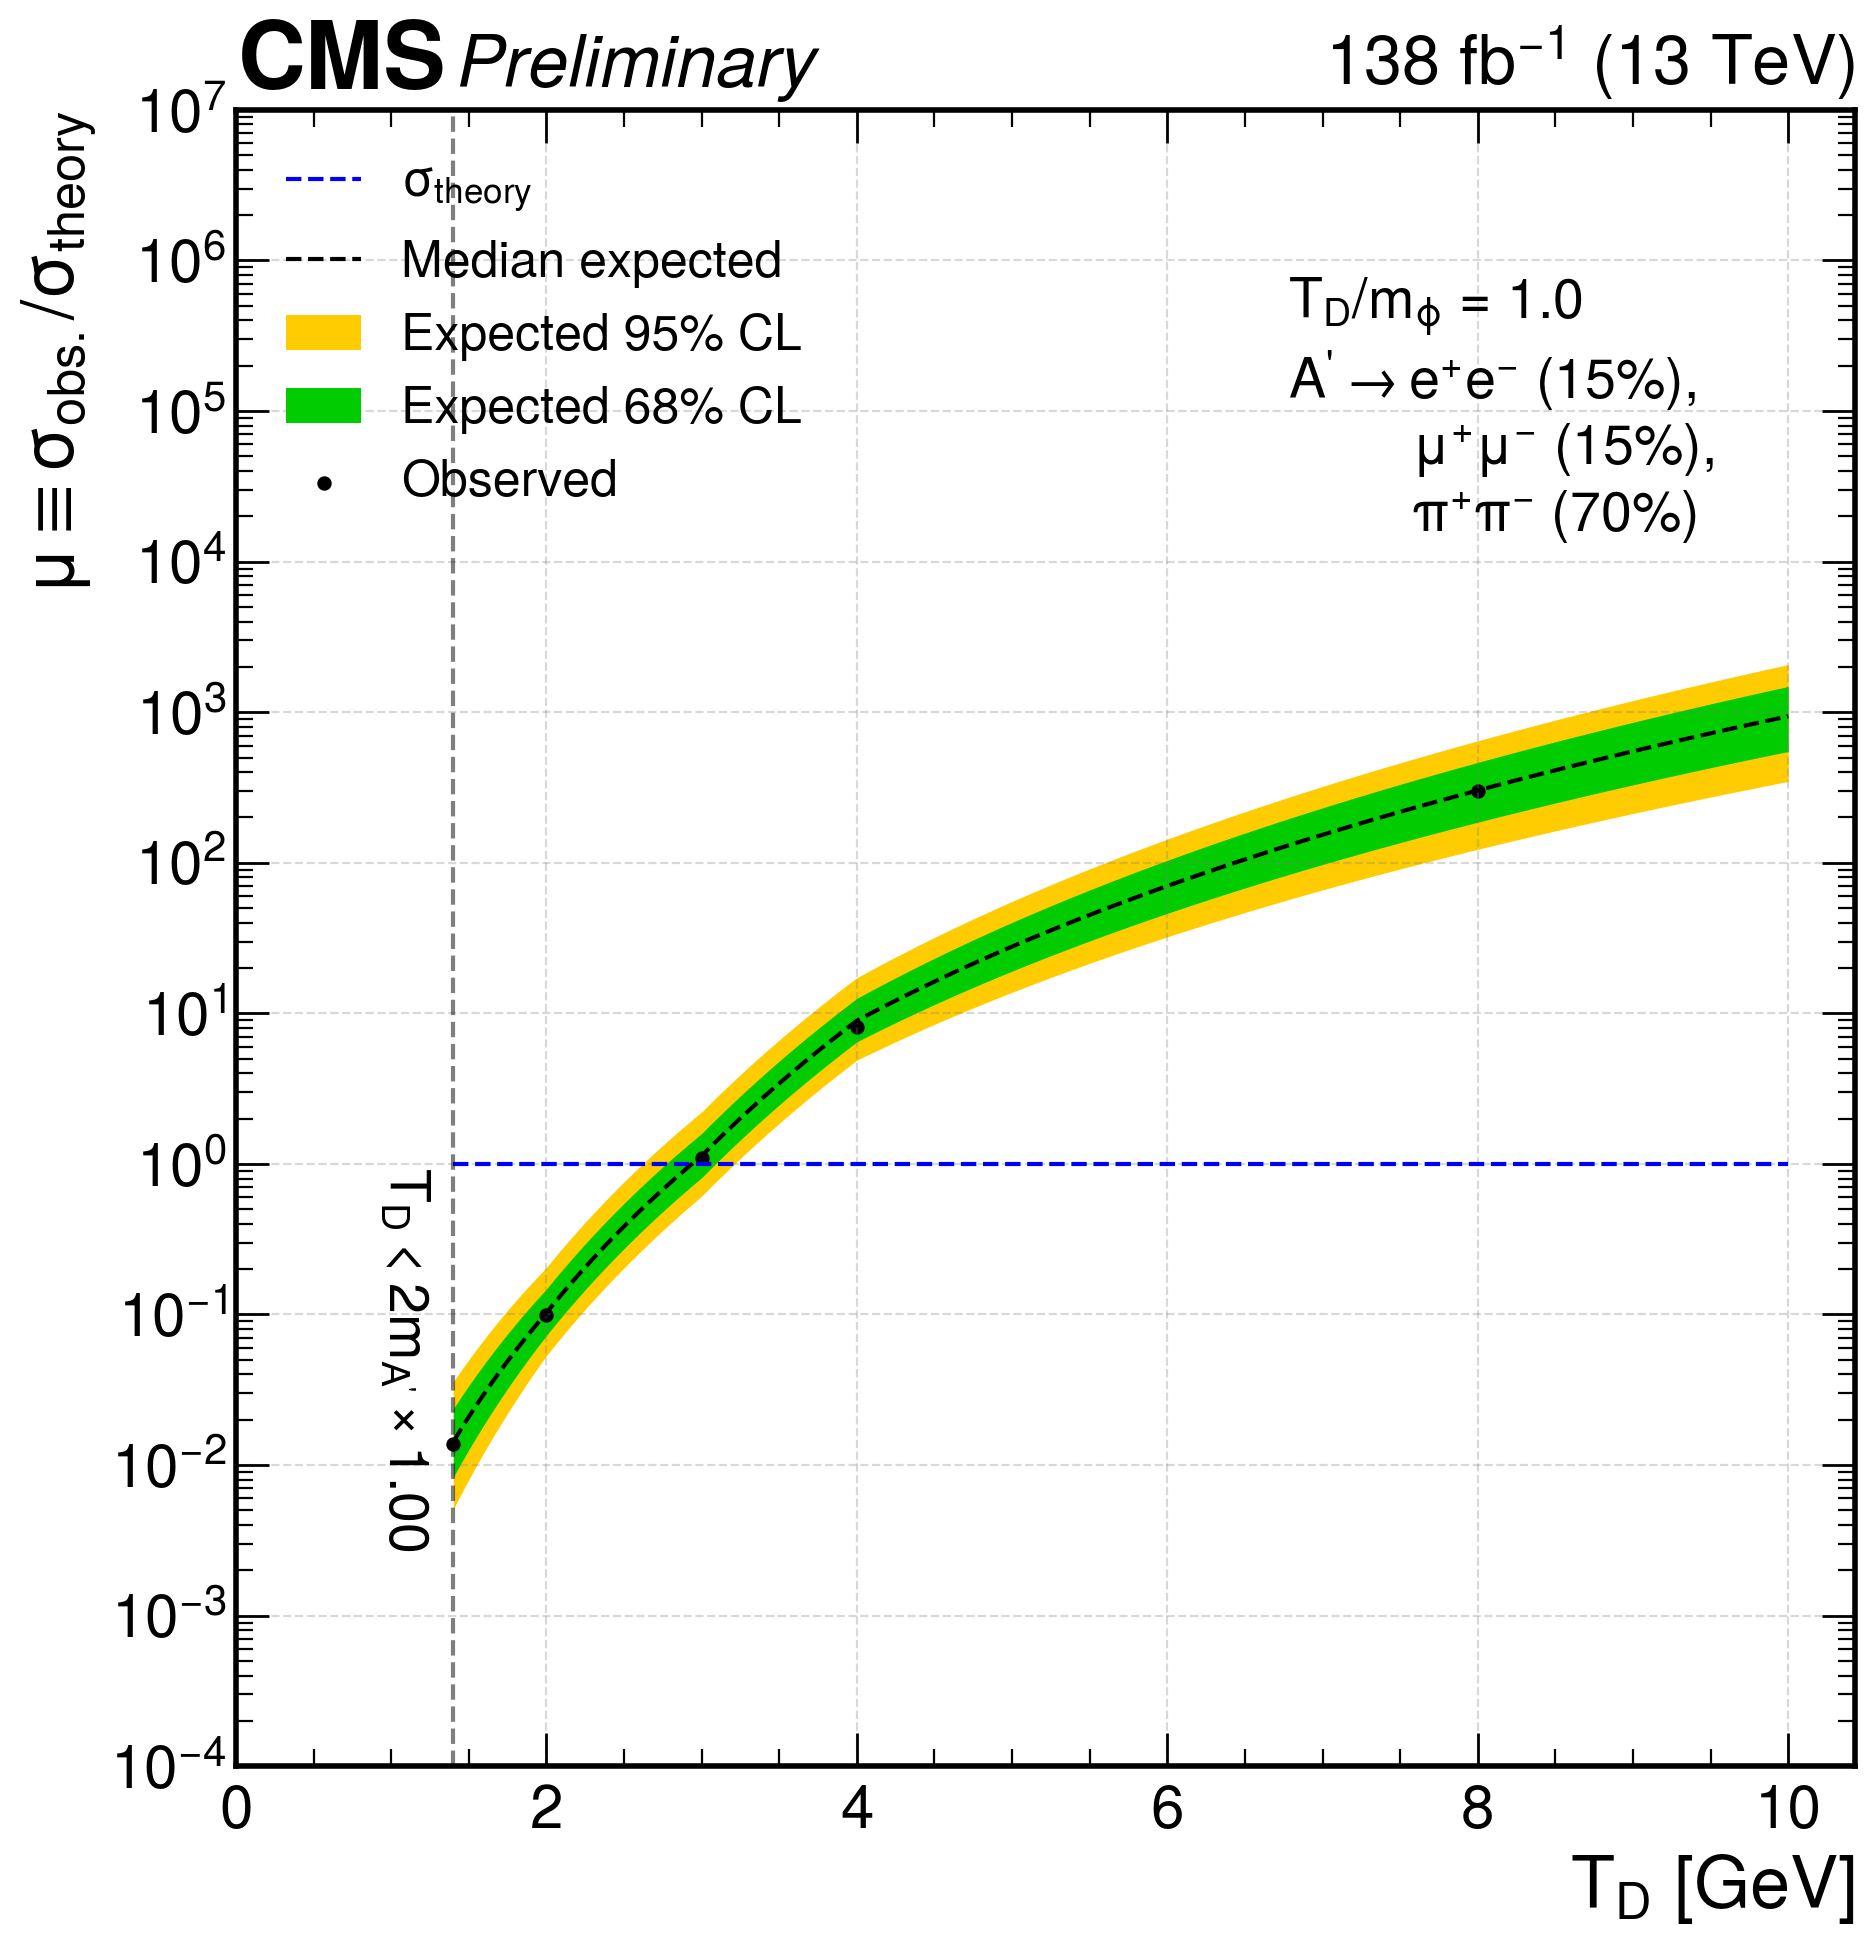

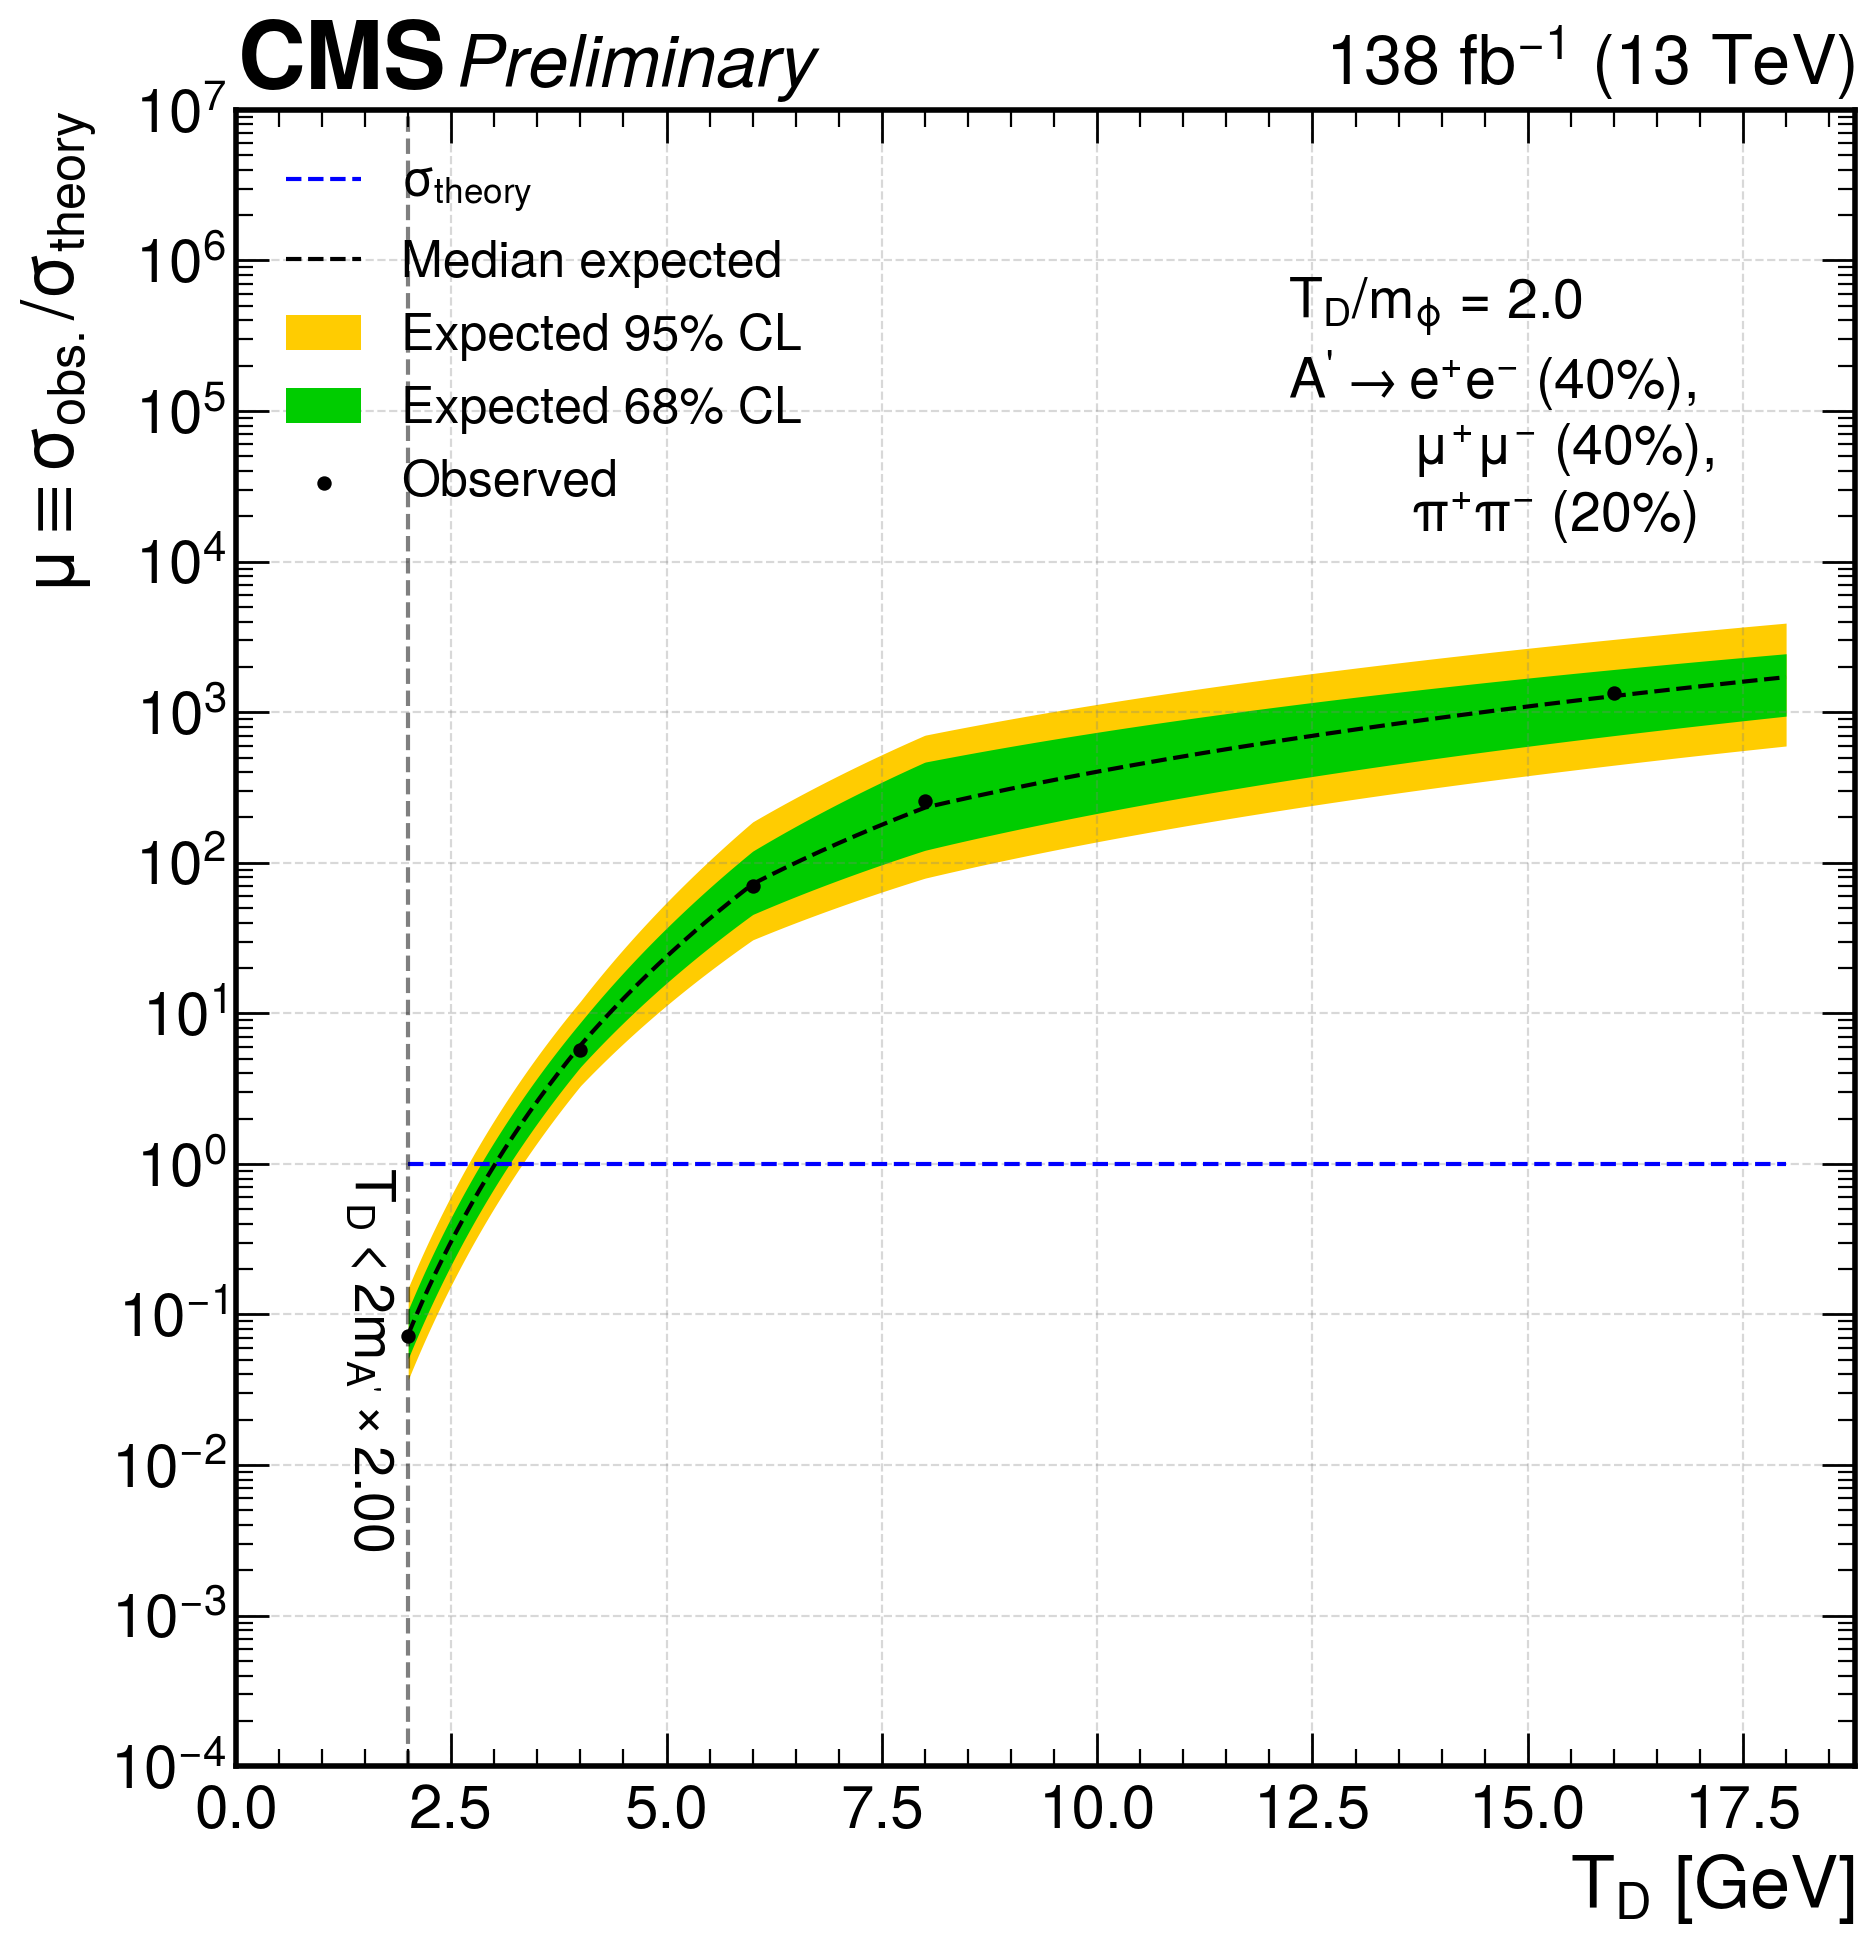

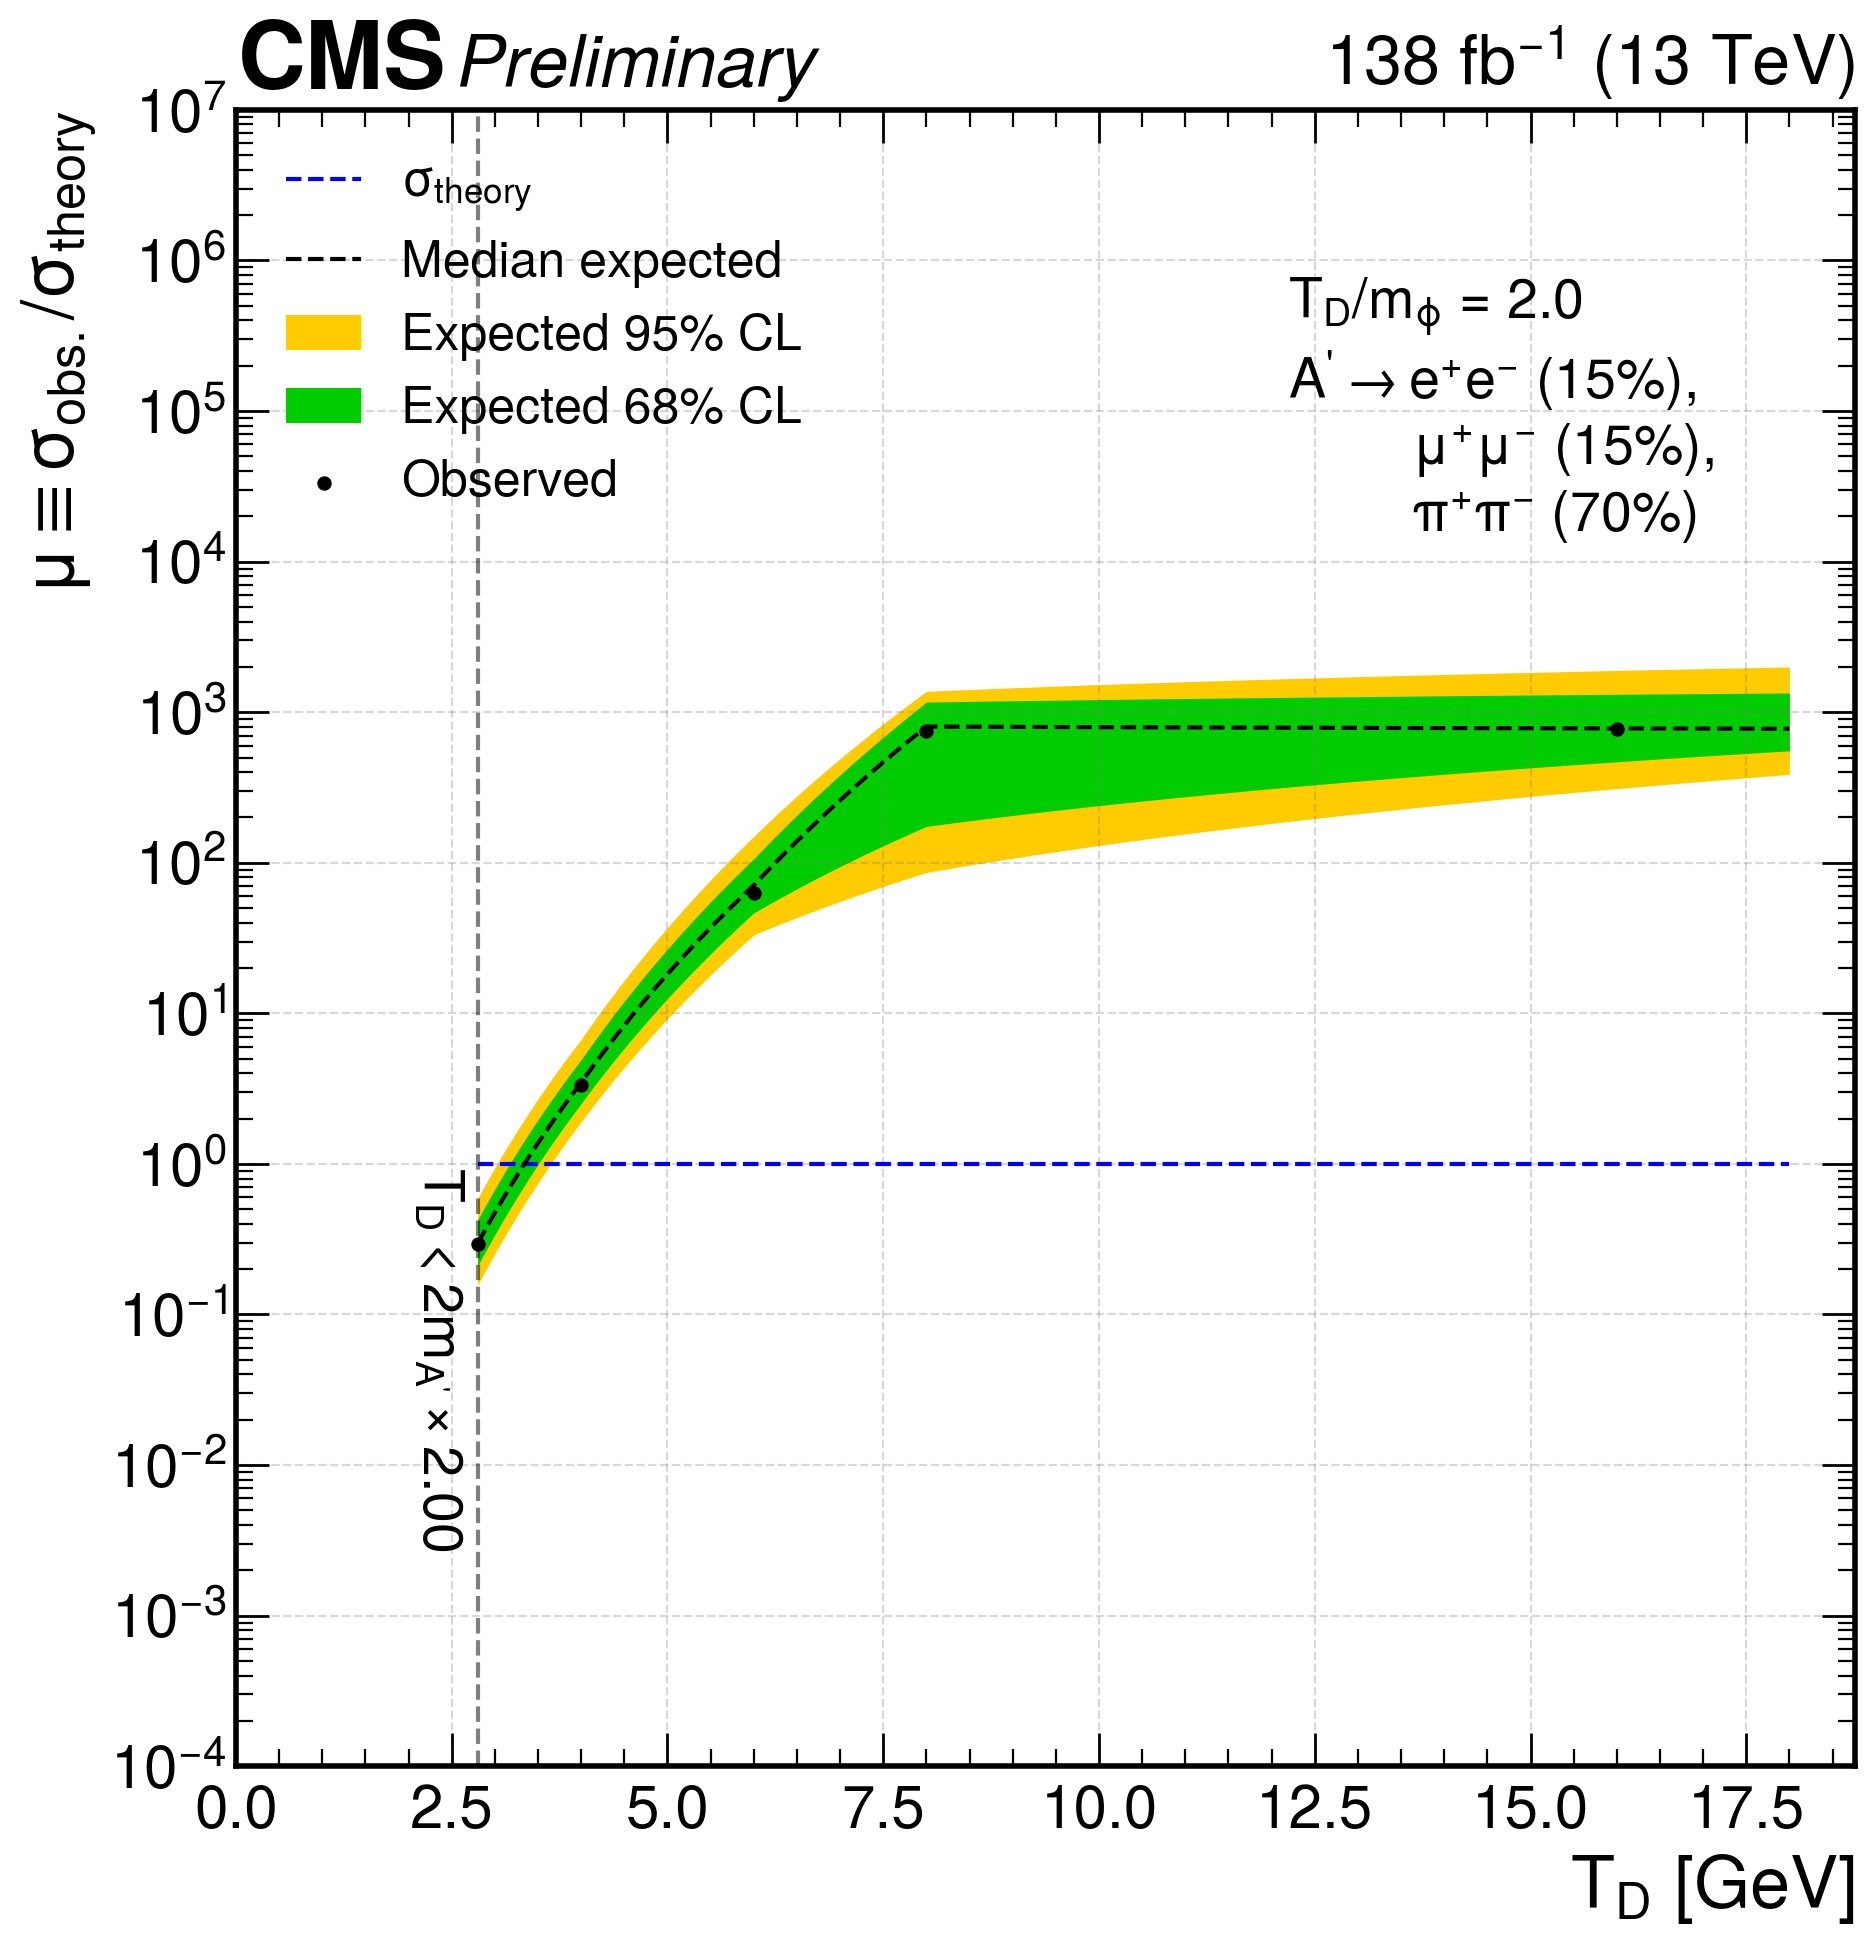

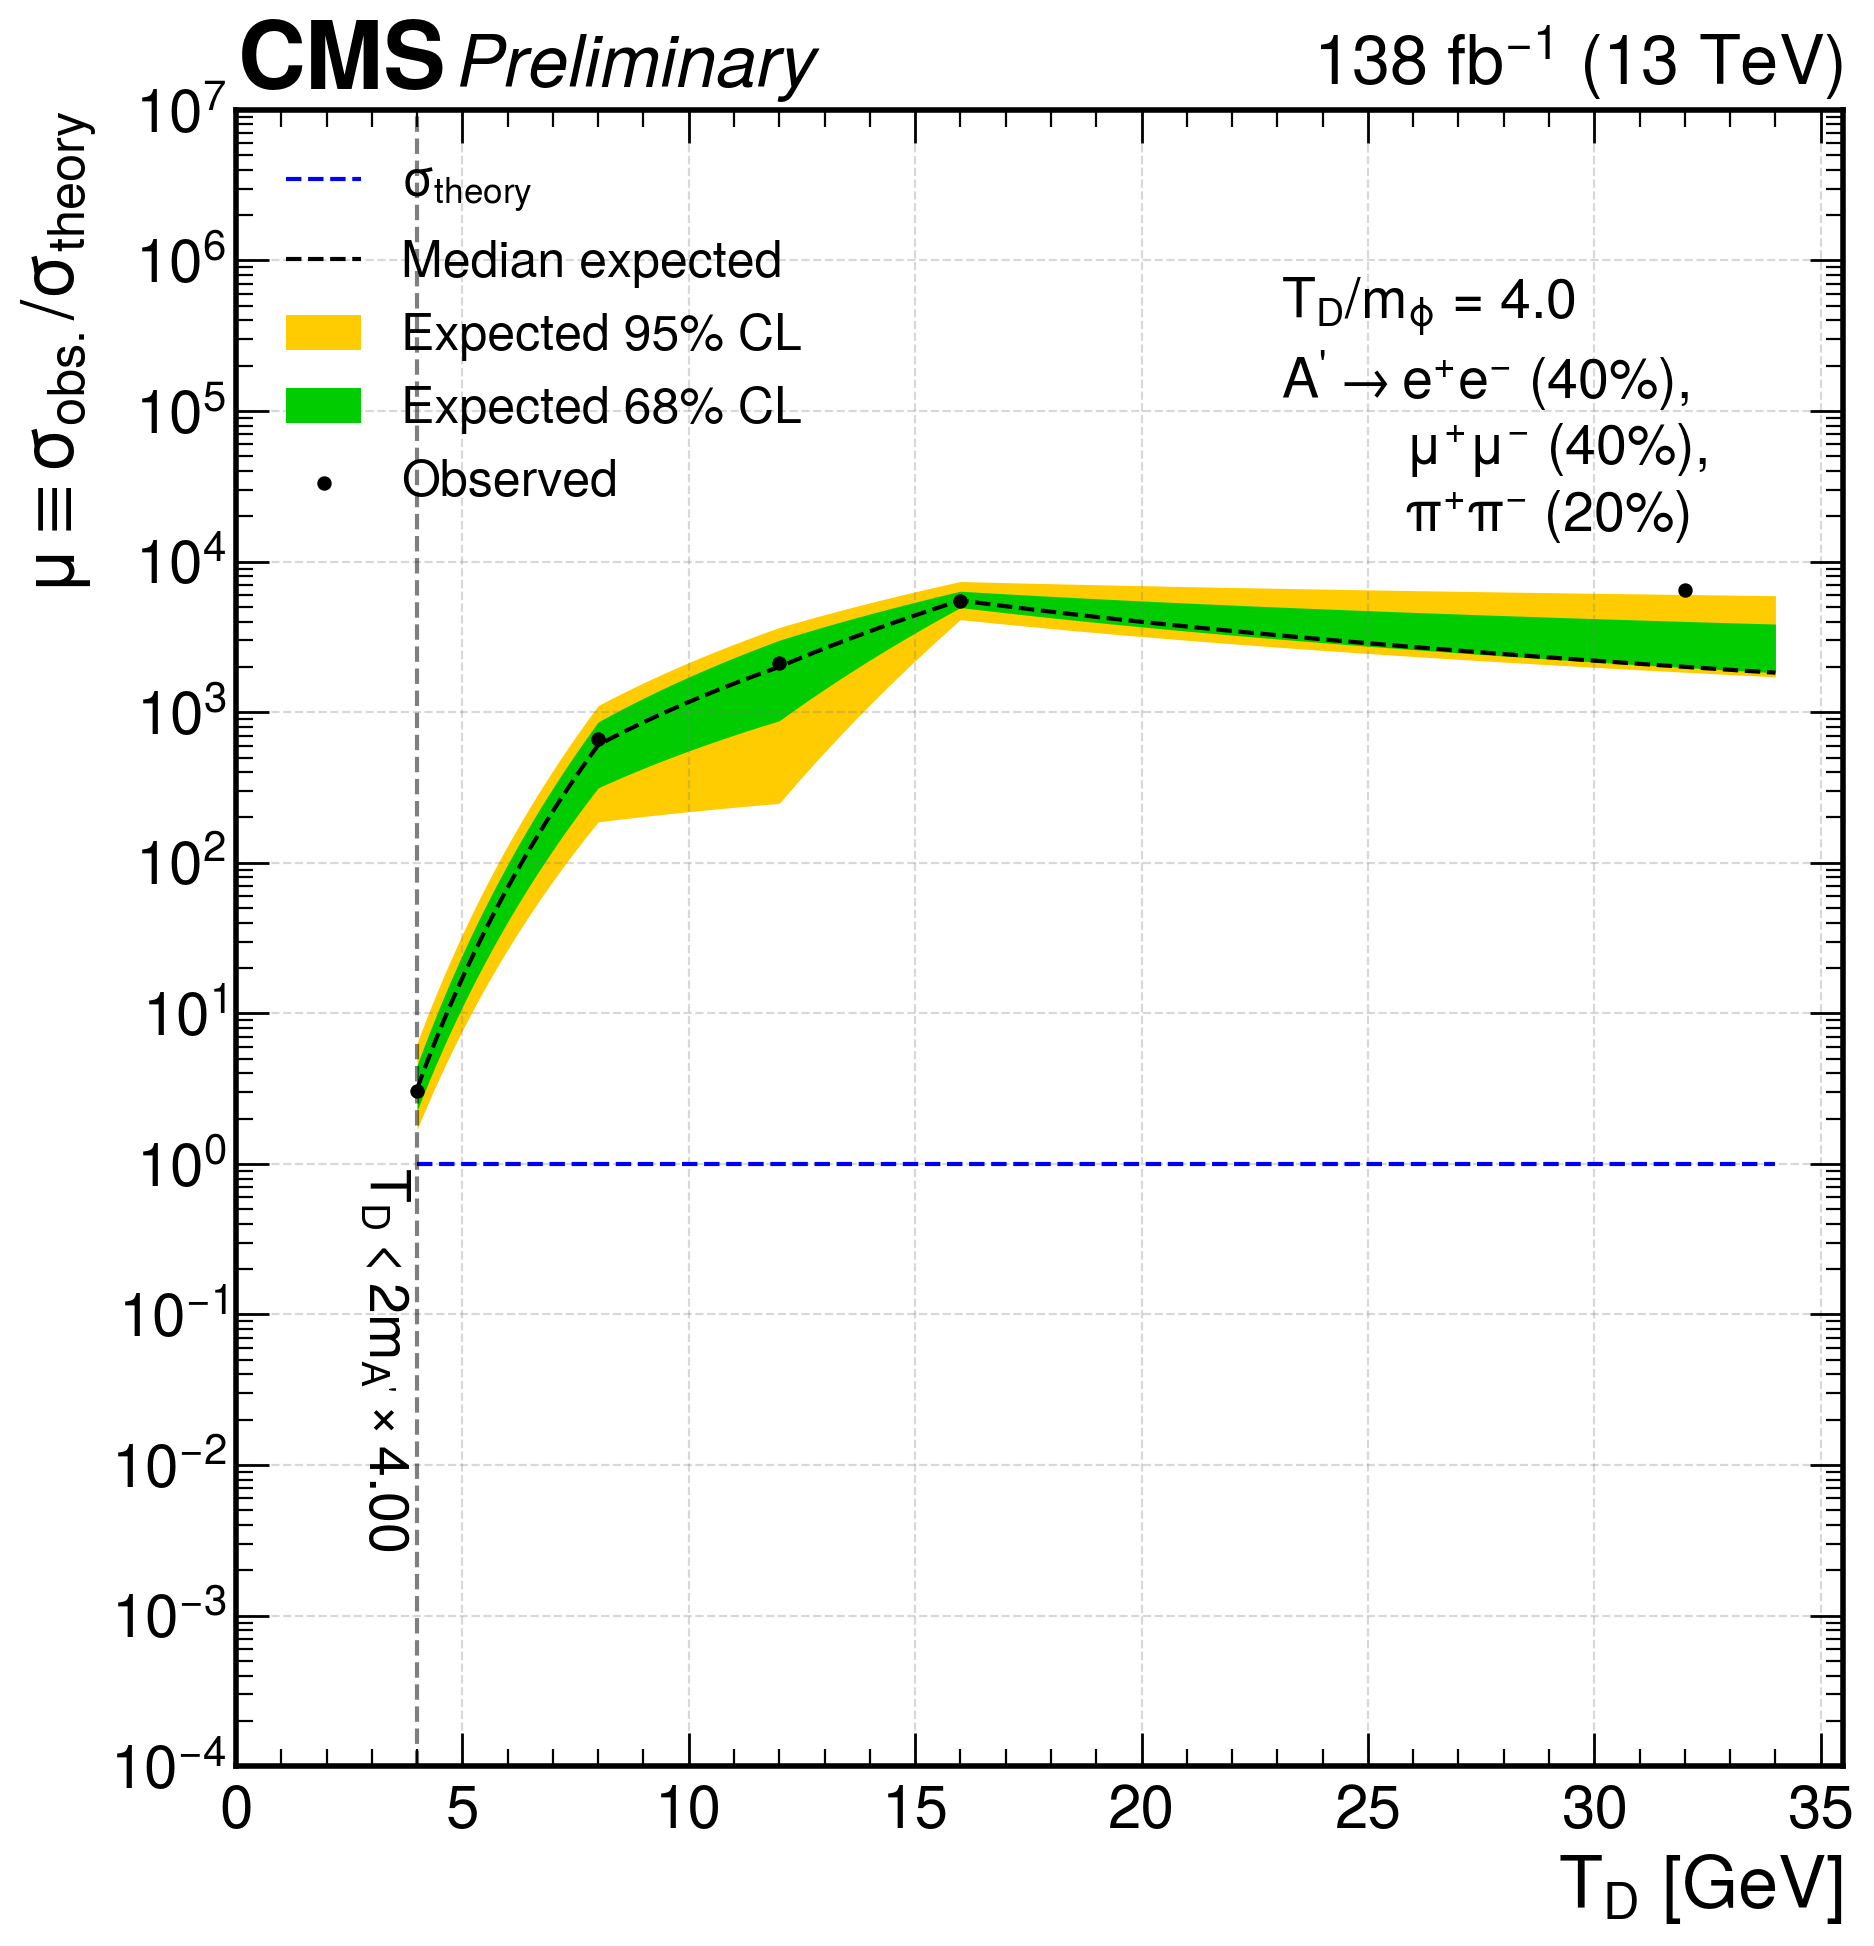

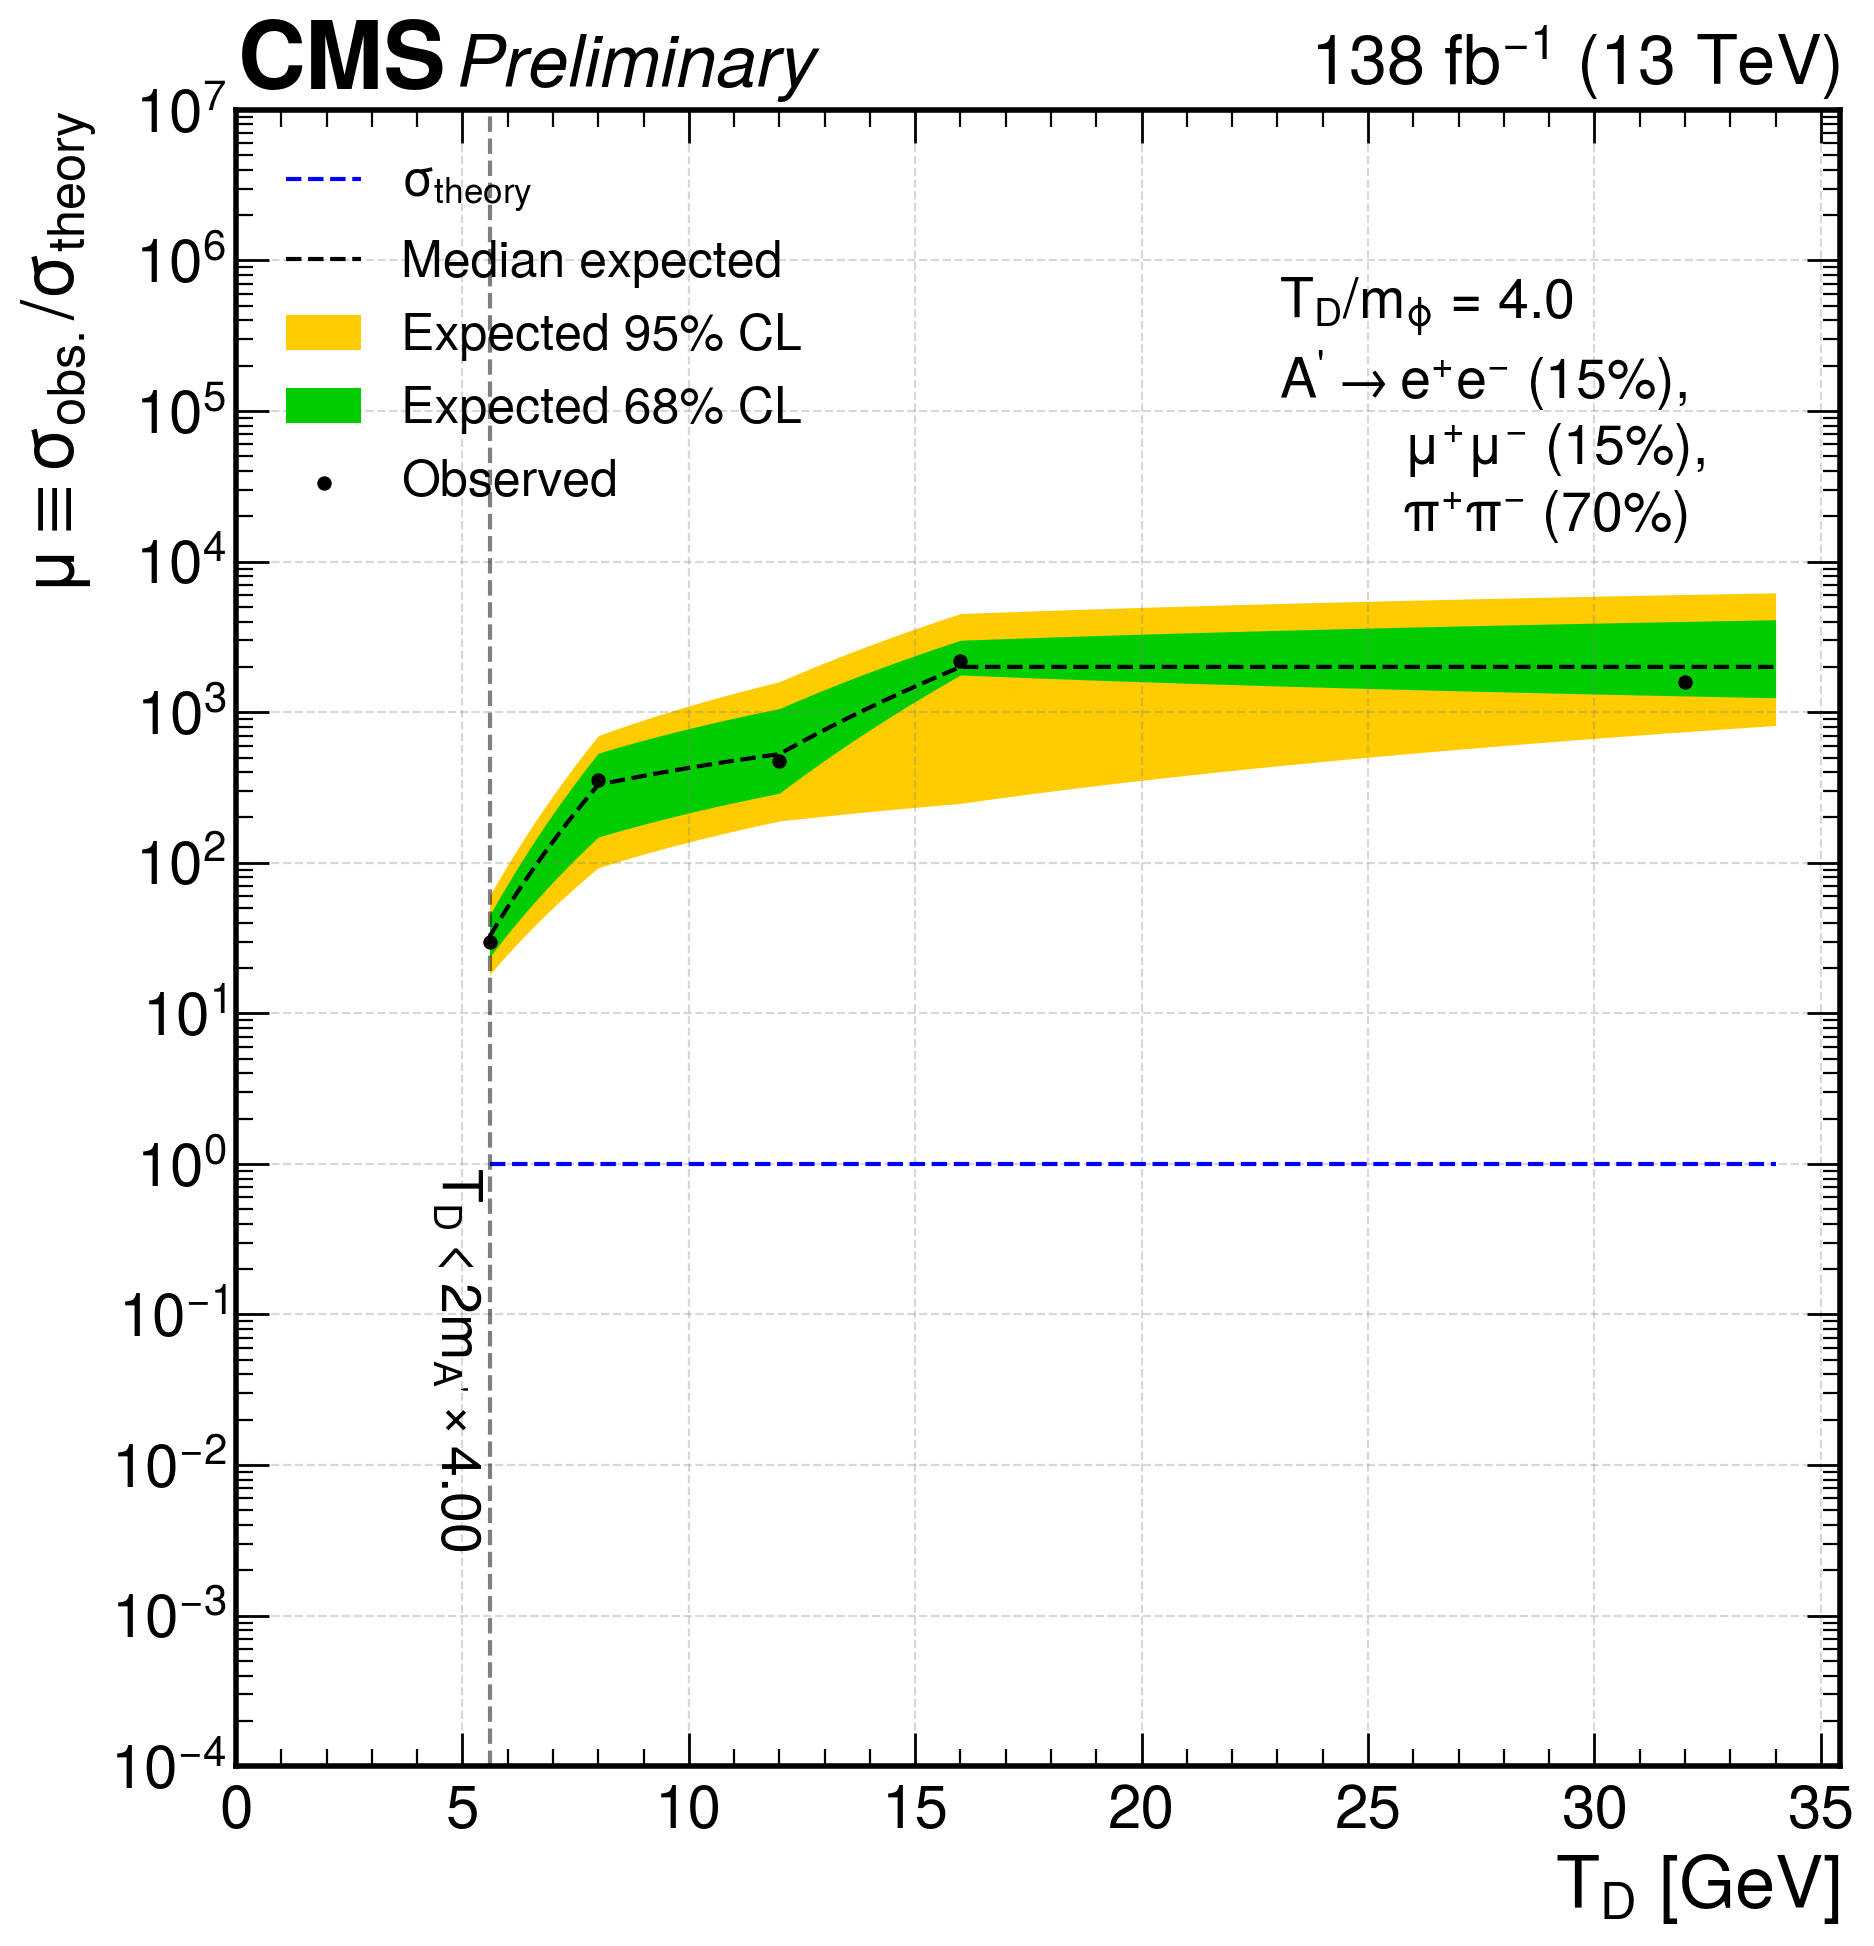

In [11]:
decay_modes = [
    'leptonic', 
    'hadronic'
    #'generic'
]
mphi_by_t = [
    0.25, 0.5, 1.0, 2.0, 4.0
]
show_zh = False

for i in mphi_by_t:
    for decay_mode in decay_modes:

        fig = plot_mphi_by_T_limits(temp_by_mphi=i, ms=125, decay=decay_mode, path=itag, obs_marker='.', method='AsymptoticLimits', analysis='wh', mu_limit=True)
        hep.cms.label(data=True, llabel='Preliminary', lumi=utils.lumis['combined'], ax=fig.get_axes()[0])

        # code for adding the ZH limits to this plot
        if show_zh:
            mask = (T/mPhi == i) & (T < 10) & ((T != 0.5) & (mPhi != 0.5) & (T != 1.0) & (mPhi != 1.0))

            xvar = np.linspace(min(T[mask]), max(T[mask])+2, 1000)
            exp_limit = utils.log_interp1d(T[mask], exp[mask]) 
            s1p_limit = utils.log_interp1d(T[mask], s1p[mask])
            s1m_limit = utils.log_interp1d(T[mask], s1m[mask])
            s2p_limit = utils.log_interp1d(T[mask], s2p[mask])
            s2m_limit = utils.log_interp1d(T[mask], s2m[mask])

            ax = fig.get_axes()[0]
            ax.plot(xvar, exp_limit(xvar), ls="--", ms=12, color='cyan', label="ZH Median expected")
            ax.fill_between(xvar, s2m_limit(xvar), s2p_limit(xvar), color="blue", alpha=0.3, lw=0, label="ZH Expected 95% CL")
            ax.fill_between(xvar, s1m_limit(xvar), s1p_limit(xvar), color="darkblue", alpha=0.3, lw=0, label="ZH Expected 68% CL")
            ax.scatter(T[mask], obs[mask], marker='*', s=70, color='cyan', label="ZH Observed") 

        # temporary: while blinded, we are using Asimov data for observed
        handles, labels = fig.get_axes()[0].get_legend_handles_labels()
        # for i in range(len(labels)):
        #     if labels[i] == "Observed": labels[i] = "Asimov Data"
        fig.get_axes()[0].legend(handles, labels, loc="upper left", fontsize='x-small')

        # if saveToAN:
        #     fig.savefig(outDirAN + fig.get_label() + '.pdf', bbox_inches='tight')

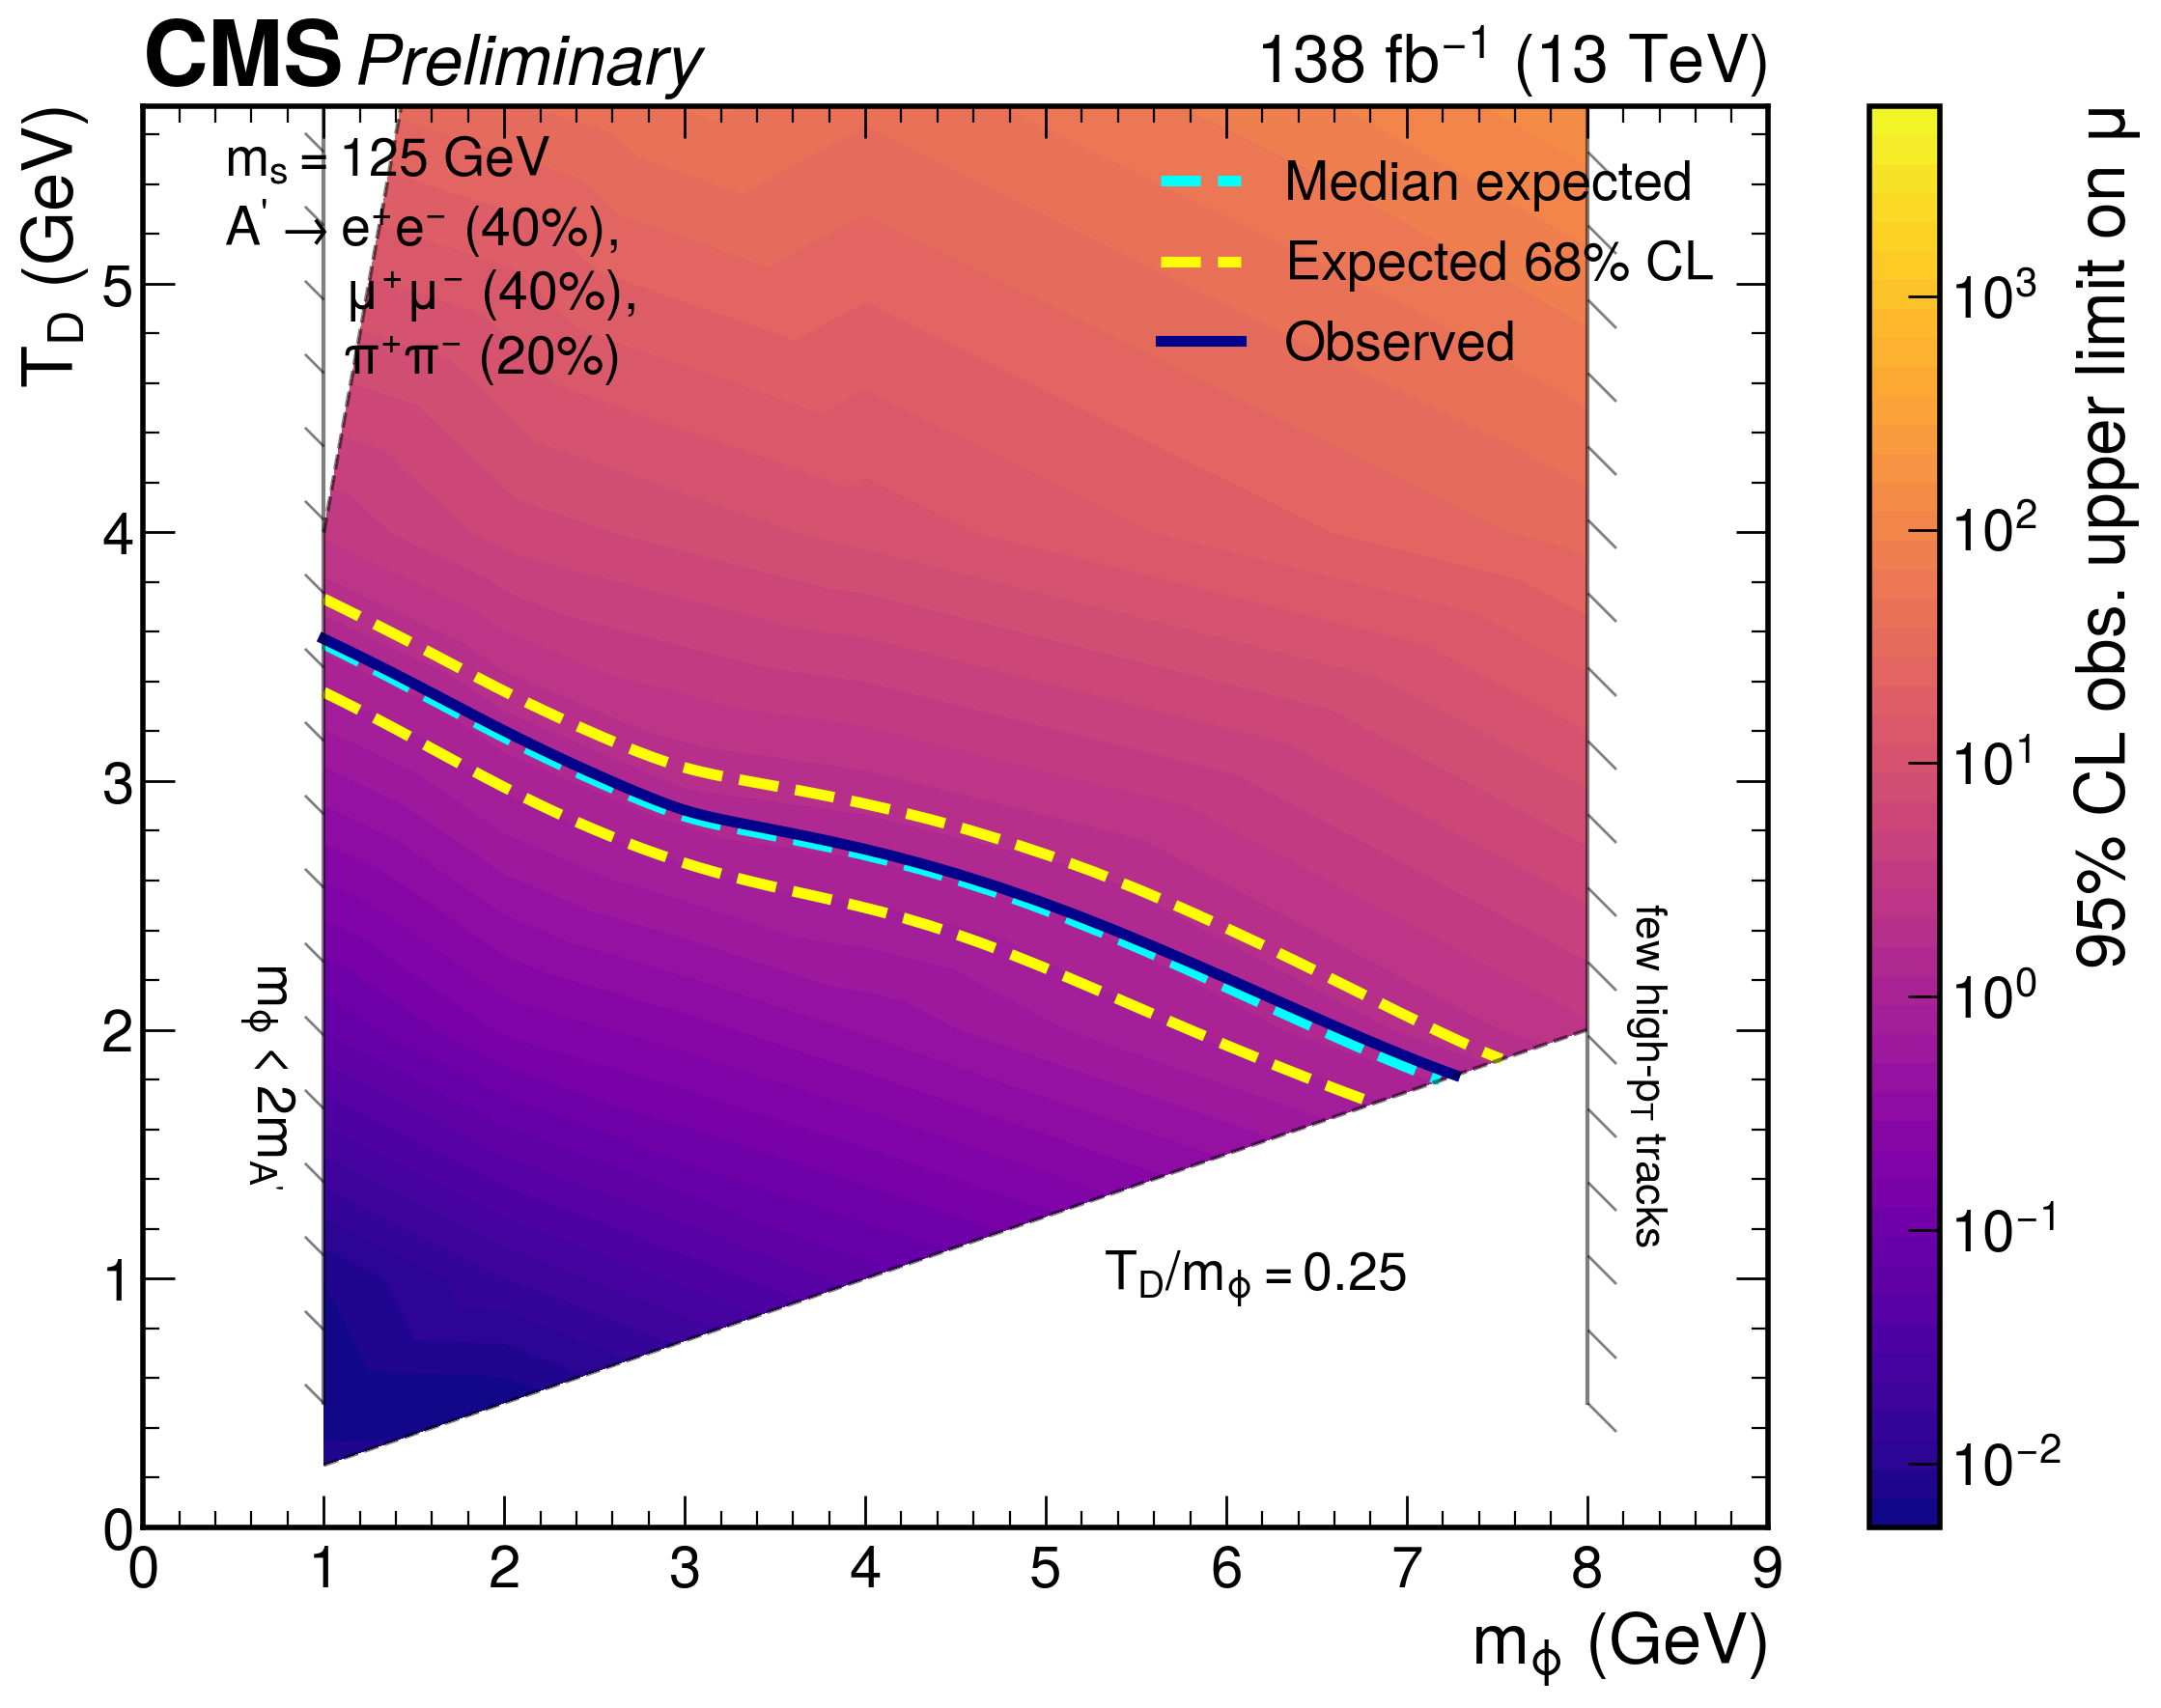

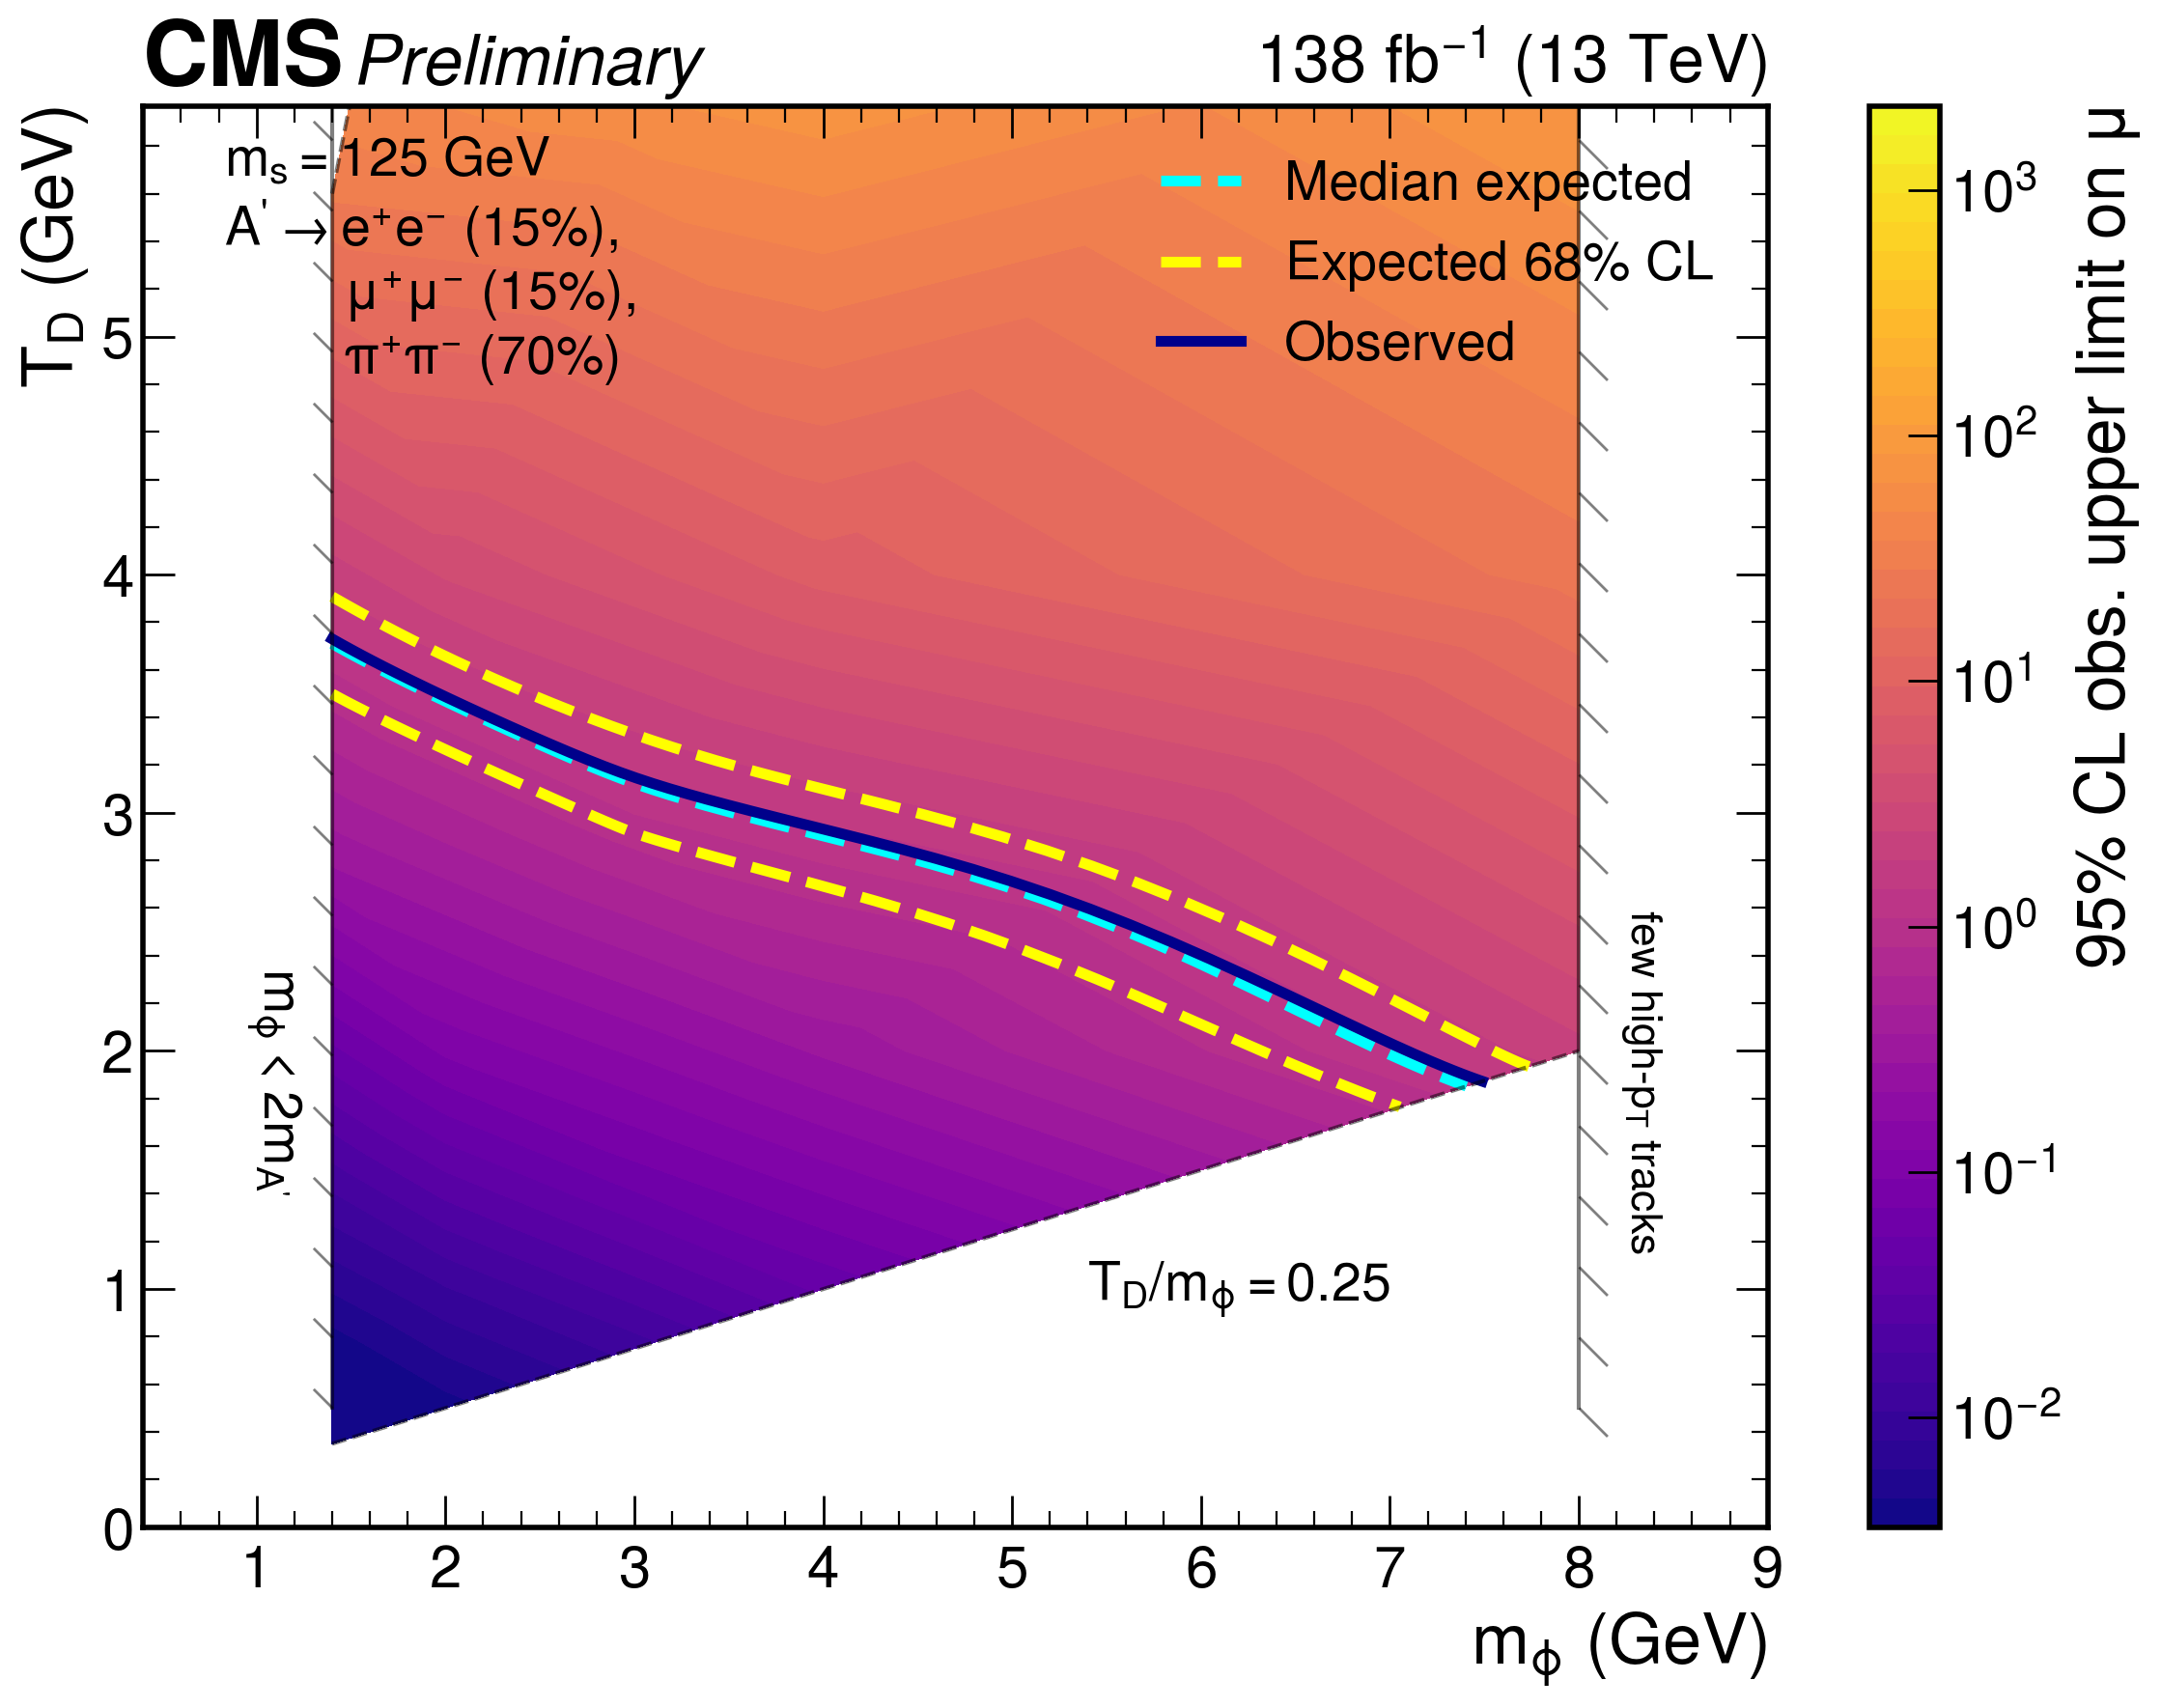

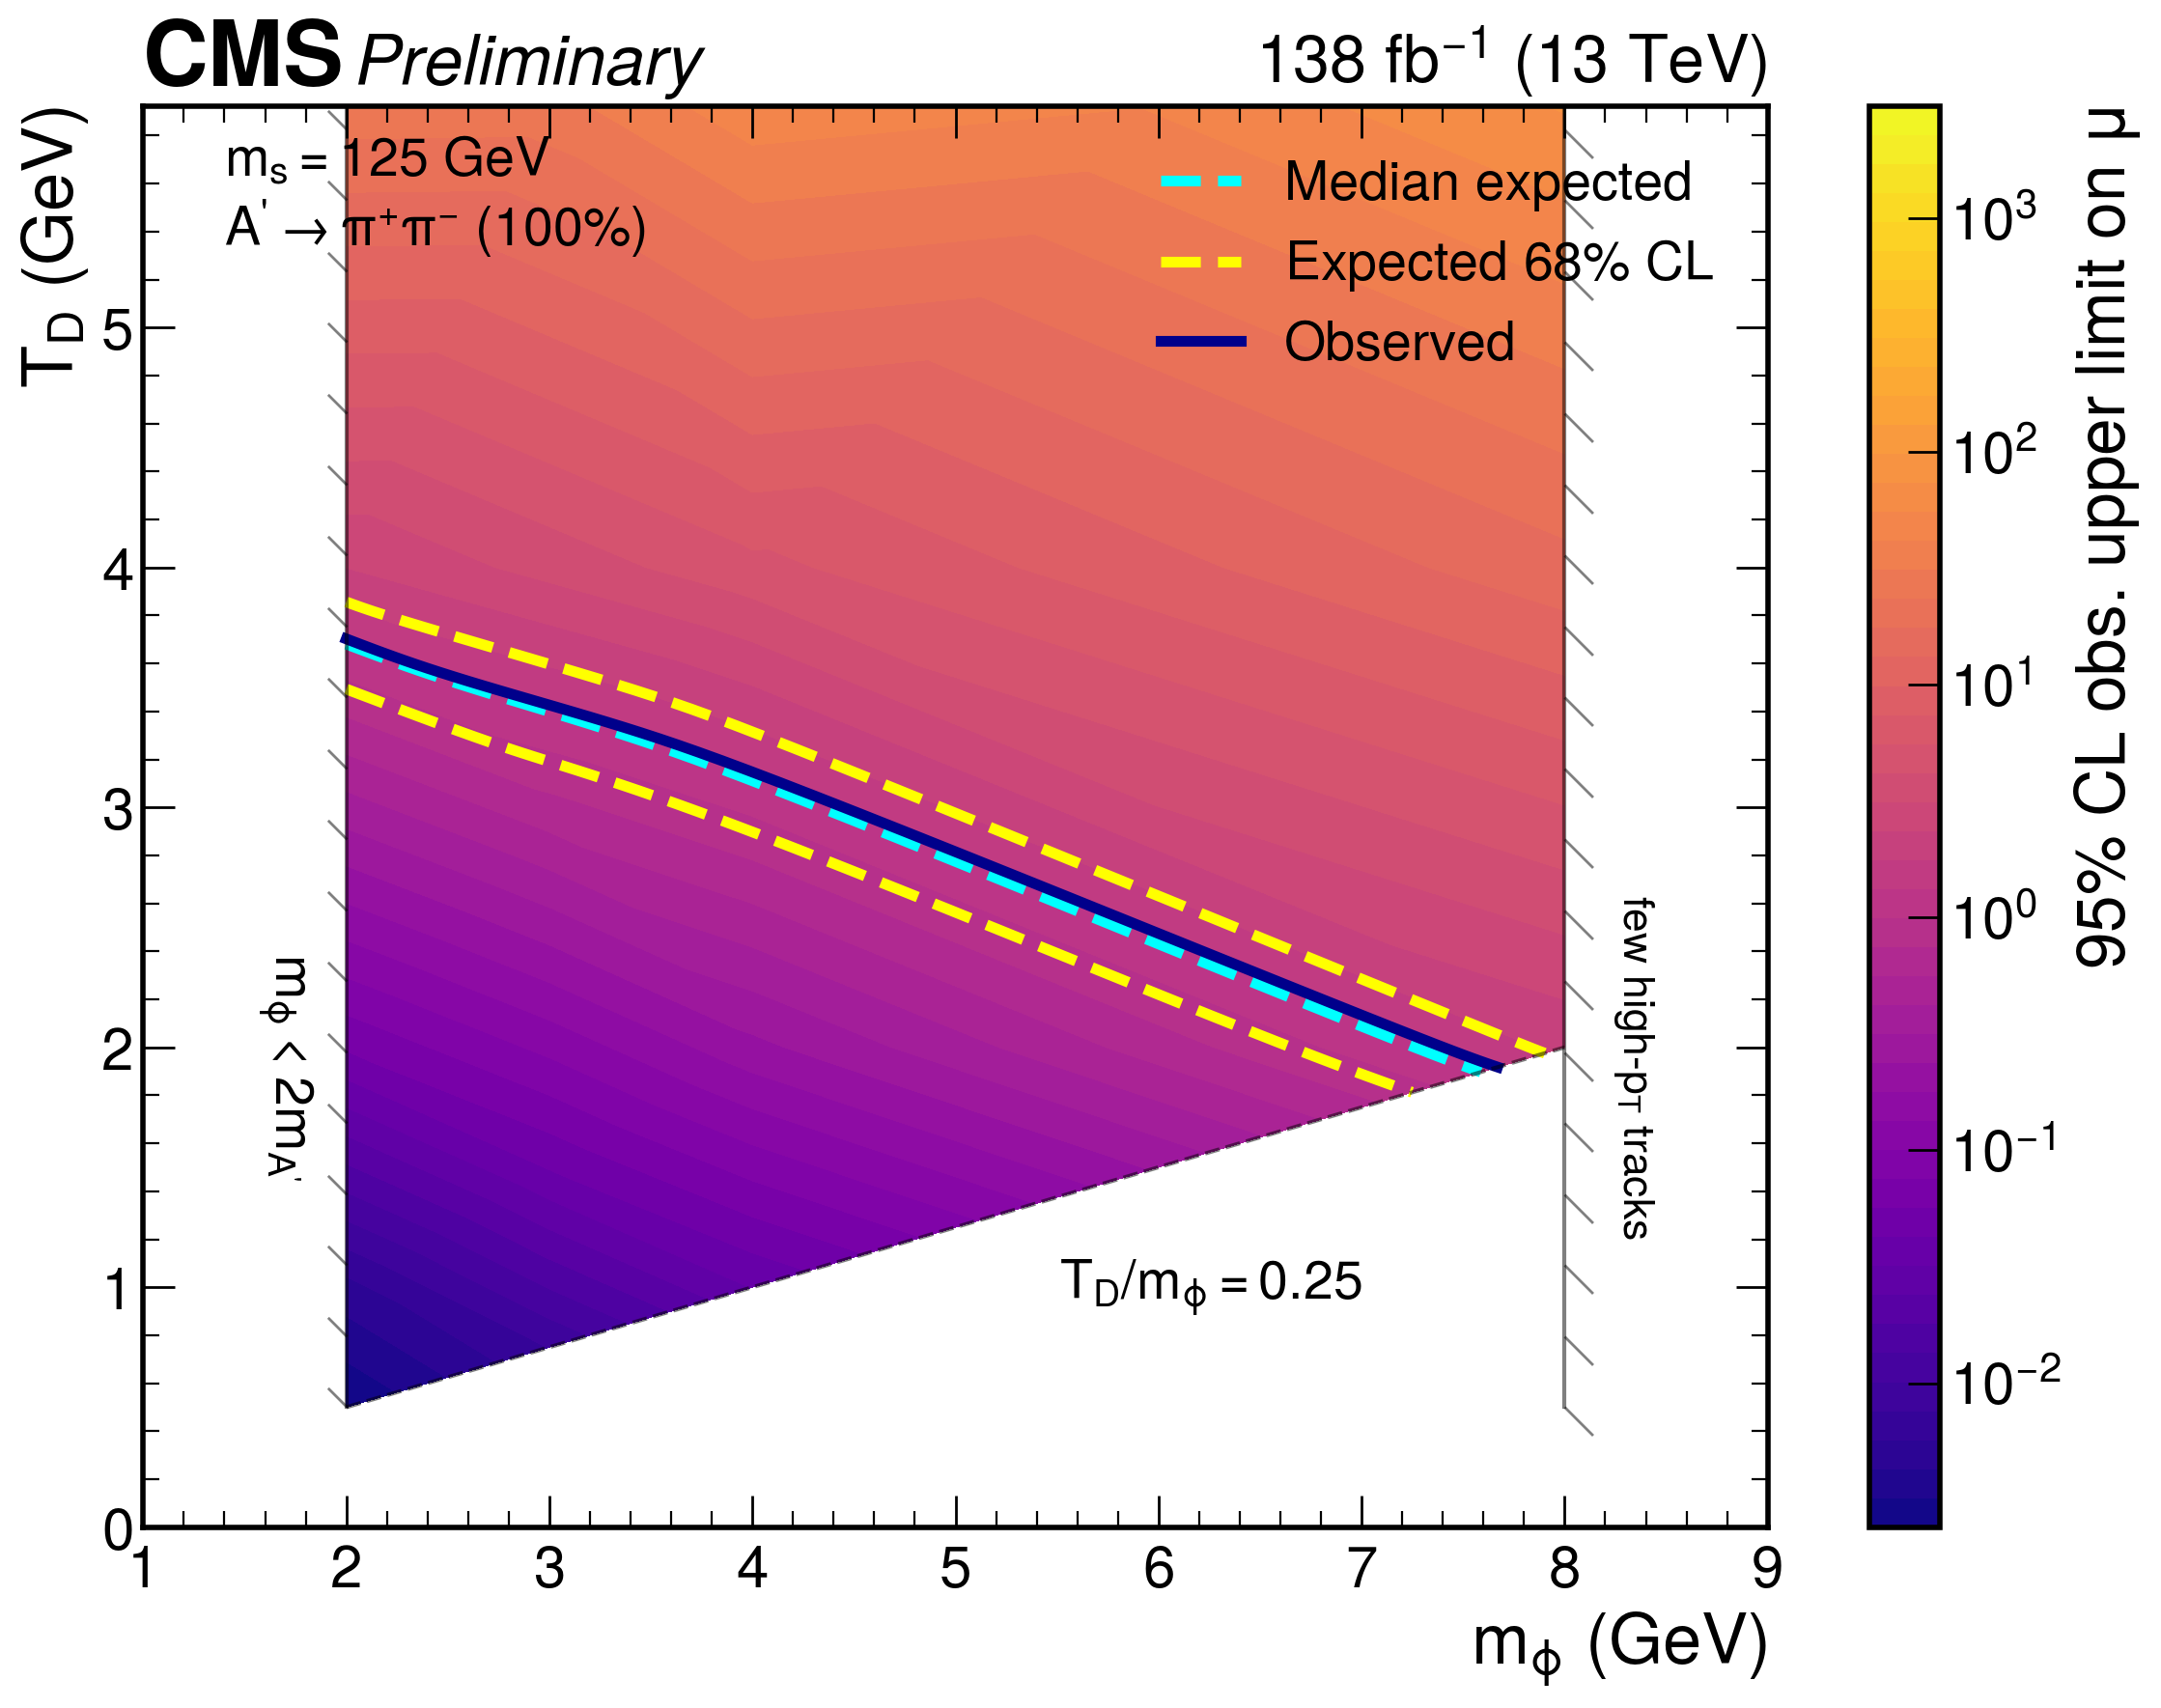

In [8]:
# example usage of the 2D limits function
decay_modes = [
    'leptonic', 'hadronic', 'generic'
]

for decay_mode in decay_modes:
    fig = utils.plot_mPhi_temp_limits(
        ms=125, analysis='wh', decay=decay_mode,
        path=itag, method='AsymptoticLimits',
        tricontour='log', showPoints=False, showObserved=True, showTheoryLines=True, cmsLabel=False, muLimit=True
    )
    _ = hep.cms.label(data=True, llabel='Preliminary', lumi=utils.lumis['combined'], ax=fig.get_axes()[0])
    if saveToAN:
        fig.savefig(outDirAN + fig.get_label() + '.pdf', bbox_inches='tight')

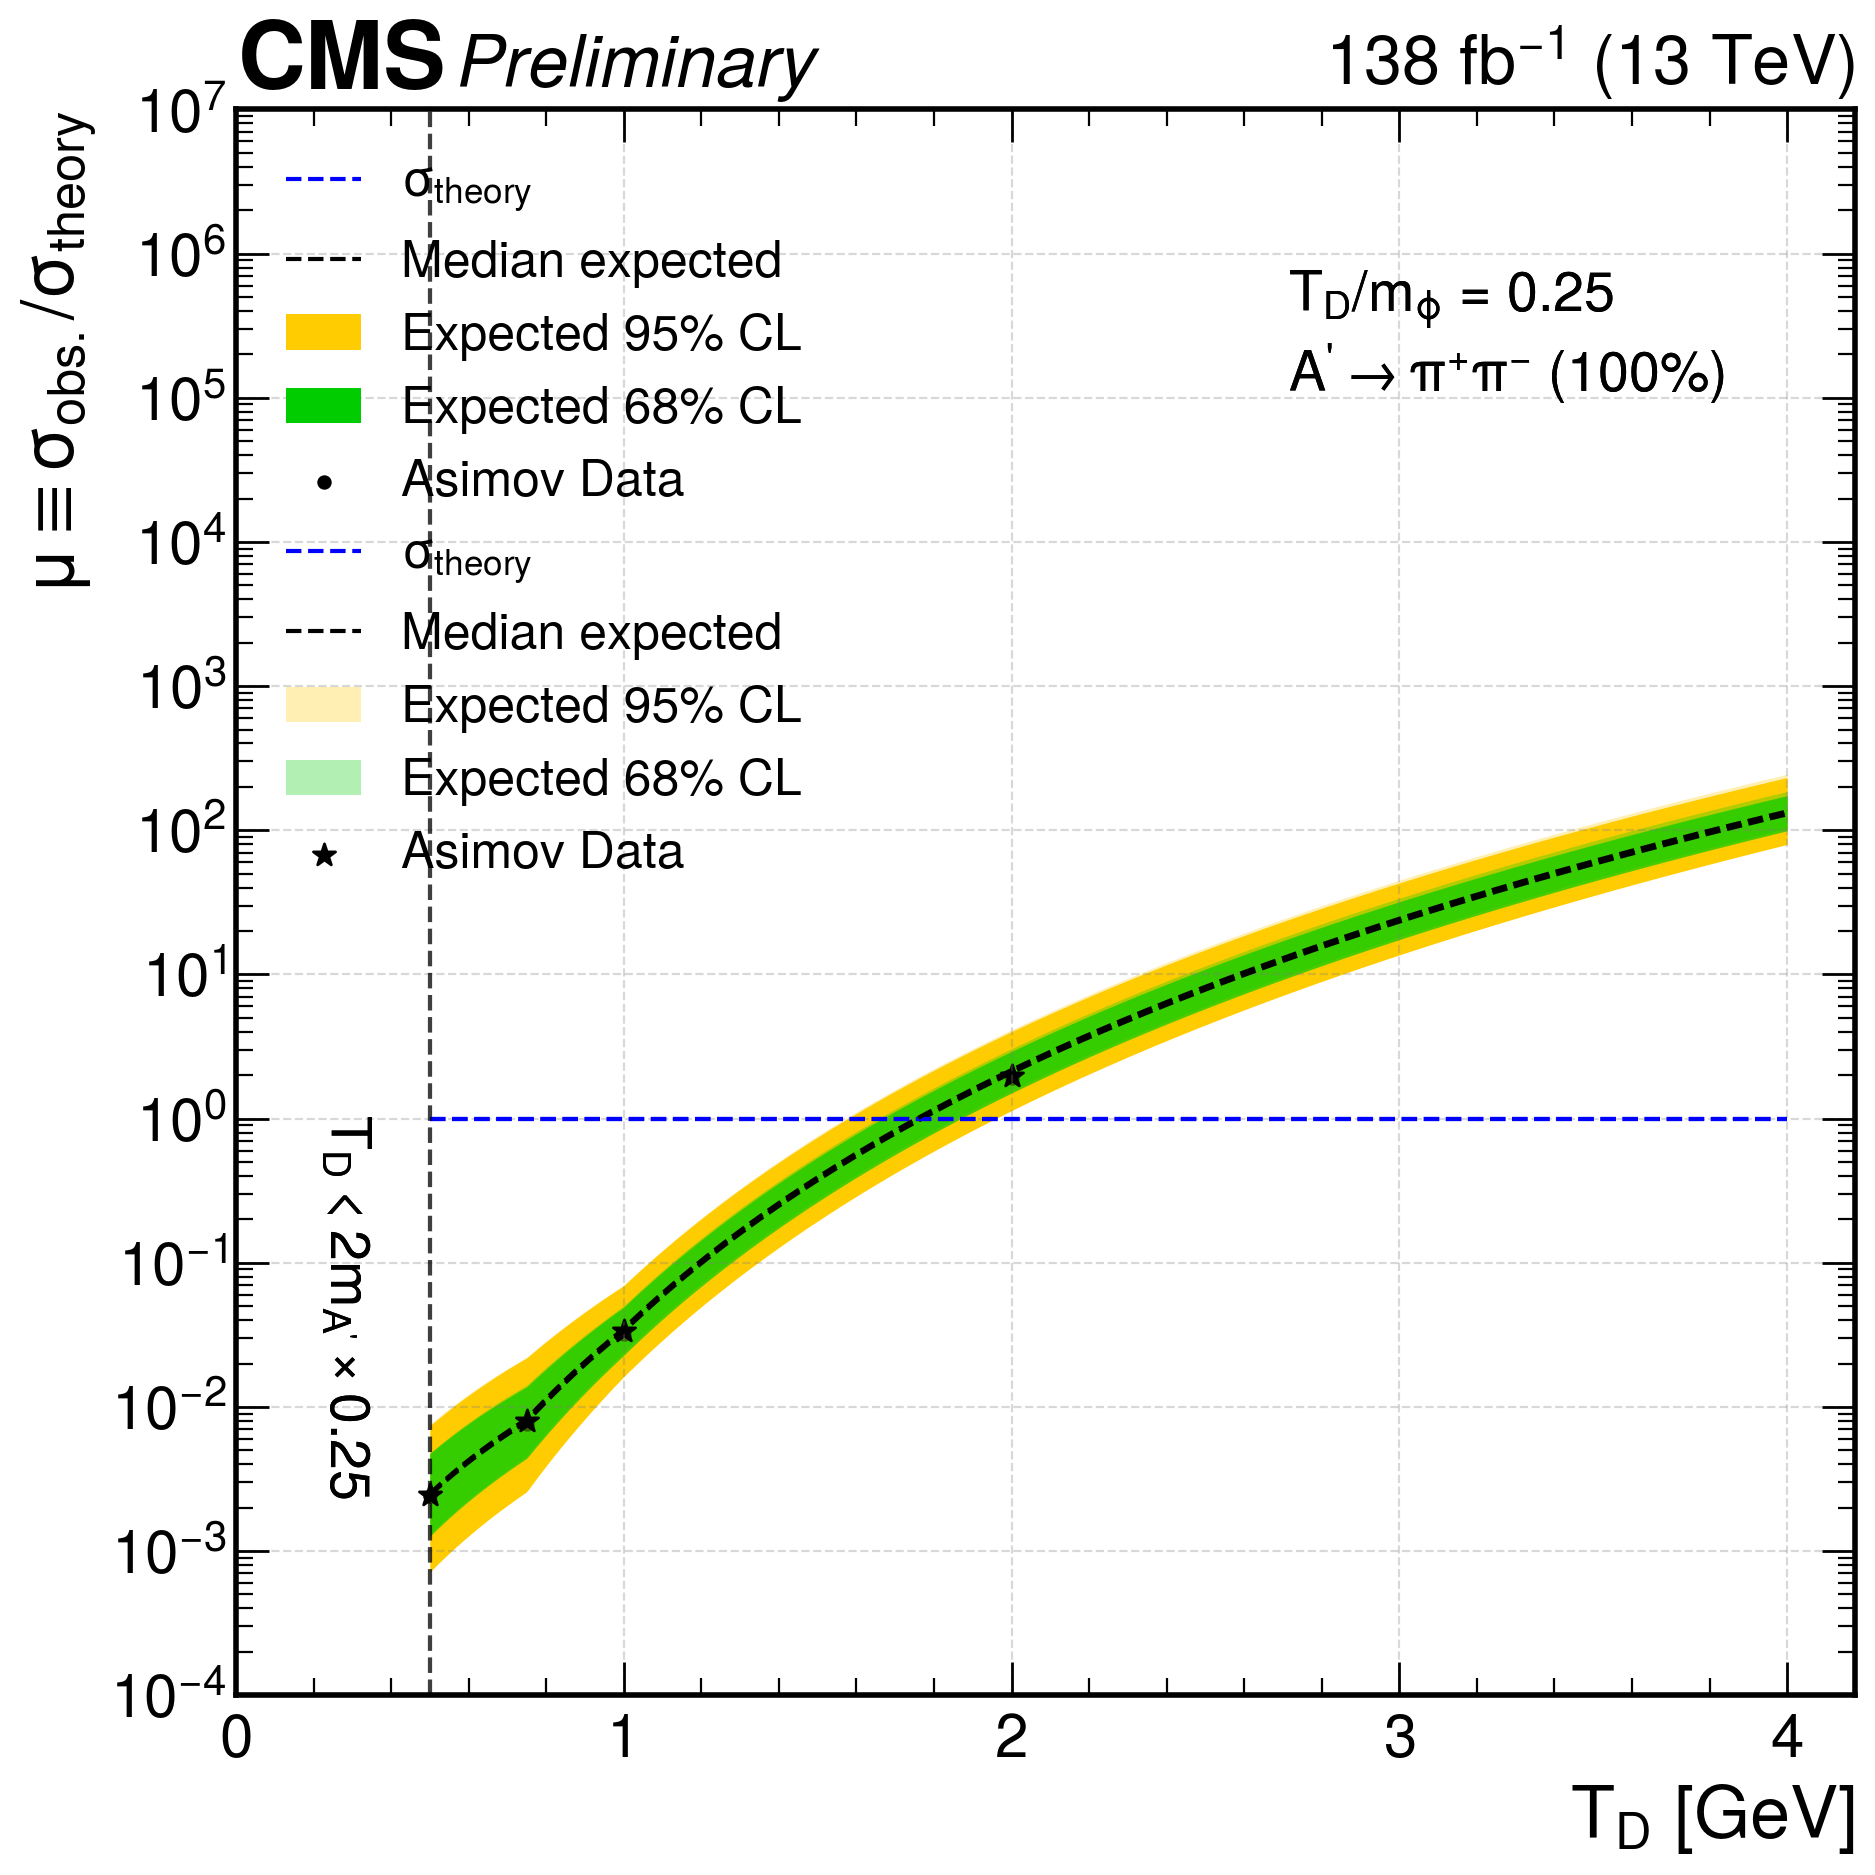

In [ ]:
mphi_by_t = [0.25, 0.5, 1.0, 2.0, 4.0]
show_zh = False

for i in mphi_by_t:
    fig = plot_mphi_by_T_limits(temp_by_mphi=i, ms=125, decay='generic', path='../cards/WH_1_25/', obs_marker='.', method='AsymptoticLimits', analysis='wh', mu_limit=True)
    hep.cms.label(data=True, llabel='Preliminary', lumi=utils.lumis['combined'], ax=fig.get_axes()[0])

    fig = plot_mphi_by_T_limits(temp_by_mphi=i, fig=fig, ax=fig.get_axes()[0], ms=125, decay='generic', path='../cards/WH_2_1/', obs_marker='*', method='AsymptoticLimits', analysis='wh', mu_limit=True, exp_alpha=0.3)

    # temporary: while blinded, we are using Asimov data for observed
    handles, labels = fig.get_axes()[0].get_legend_handles_labels()
    for i in range(len(labels)):
        if labels[i] == "Observed": labels[i] = "Asimov Data"
    fig.get_axes()[0].legend(handles, labels, loc="upper left", fontsize='x-small')